## Cell 1 — Imports & Session Timer


In [1]:
import os, time, json, subprocess, shutil
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

SESSION_START     = time.time()
SESSION_LIMIT_HRS = 11.0

def hours_elapsed():
    return (time.time() - SESSION_START) / 3600

def session_ok(buffer_hrs=0.5):
    """Returns False when within buffer_hrs of the 11-hr Kaggle limit."""
    return hours_elapsed() < (SESSION_LIMIT_HRS - buffer_hrs)

print(f'Session limit: {SESSION_LIMIT_HRS} hrs')


Device: cuda
GPU : NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM: 102.0 GB
Session limit: 11.0 hrs


## Cell 2 — Streaming Multi-Part Extraction
No combined zip is ever written to disk. Peak disk usage ~6–8 GB per modality.


In [2]:
import io, zipfile, shutil
from pathlib import Path

# ── Locate the 9 zip parts (recursive — works with any dataset layout) ────
INPUT_BASE = Path('/kaggle/input')

parts = sorted(
    [
        f for f in INPUT_BASE.rglob('*')
        if f.is_file()
        and f.name.upper().startswith('MMRDR.ZIP.')
        and f.suffix.lstrip('.').isdigit()
    ],
    key=lambda p: int(p.suffix.lstrip('.'))
)

print(f'Found {len(parts)} zip parts:')
for p in parts:
    print(f'  {p}  ({p.stat().st_size / 1e6:.1f} MB)')

if len(parts) == 0:
    print('\nDebug — all files under /kaggle/input:')
    for f in sorted(INPUT_BASE.rglob('*')):
        if f.is_file():
            print(f'  {f}')

assert len(parts) == 9, (
    f'Expected 9 parts, found {len(parts)}. '
    f'Attach the dataset containing MMRDR.zip.001 to MMRDR.zip.009 via Add Data.'
)

total_zip_gb = sum(p.stat().st_size for p in parts) / 1e9
free_gb = shutil.disk_usage('/kaggle/working').free / 1e9
print(f'Total compressed : {total_zip_gb:.2f} GB')
print(f'Free disk space  : {free_gb:.2f} GB')
print('Strategy         : streaming extraction (no combined zip on disk)')


class MultiPartReader(io.RawIOBase):
    """
    Treats N split-zip part files as a single, seekable byte stream.
    No data is ever copied to disk.
    """
    def __init__(self, paths):
        self._paths   = list(paths)
        self._sizes   = [p.stat().st_size for p in self._paths]
        self._offsets = []
        off = 0
        for s in self._sizes:
            self._offsets.append(off)
            off += s
        self._total = off
        self._pos   = 0
        self._fh    = None
        self._cur   = -1

    def readable(self):  return True
    def seekable(self):  return True

    def readinto(self, b):
        if self._pos >= self._total:
            return 0
        n_want, n_read = len(b), 0
        while n_want > 0 and self._pos < self._total:
            idx      = self._part_for(self._pos)
            part_off = self._pos - self._offsets[idx]
            avail    = self._sizes[idx] - part_off
            to_read  = min(n_want, avail)
            self._open_part(idx)
            self._fh.seek(part_off)
            chunk  = self._fh.read(to_read)
            actual = len(chunk)
            if actual == 0:
                break
            b[n_read:n_read + actual] = chunk
            n_read    += actual
            n_want    -= actual
            self._pos += actual
        return n_read

    def seek(self, pos, whence=0):
        if   whence == 0: self._pos = pos
        elif whence == 1: self._pos = self._pos + pos
        elif whence == 2: self._pos = self._total + pos
        self._pos = max(0, min(self._pos, self._total))
        return self._pos

    def tell(self): return self._pos

    def _part_for(self, pos):
        lo, hi = 0, len(self._offsets) - 1
        while lo < hi:
            mid = (lo + hi + 1) // 2
            if self._offsets[mid] <= pos: lo = mid
            else:                         hi = mid - 1
        return lo

    def _open_part(self, idx):
        if self._cur != idx:
            if self._fh: self._fh.close()
            self._fh  = open(self._paths[idx], 'rb')
            self._cur = idx

    def close(self):
        if self._fh: self._fh.close()
        super().close()


EXTRACT_BASE = Path('/kaggle/working/mmrdr_extracted')
EXTRACT_BASE.mkdir(parents=True, exist_ok=True)
_READ_BUFFER = 4 << 20  # 4 MB


def _open_virtual_zip():
    raw = MultiPartReader(parts)
    buf = io.BufferedReader(raw, buffer_size=_READ_BUFFER)
    return zipfile.ZipFile(buf, 'r')


def _zip_prefix_for(modality_name):
    with _open_virtual_zip() as zf:
        members = zf.namelist()
    for prefix in [f'MMRDR/{modality_name}/', f'{modality_name}/']:
        if any(m.startswith(prefix) for m in members):
            return prefix
    top = sorted({m.split('/')[0] for m in members if m})
    raise FileNotFoundError(
        f'Cannot find {modality_name!r} in zip. Top-level folders: {top}'
    )


def extract_modality(modality_name, dest_dir=None):
    """Stream-extract one modality. The combined zip is NEVER written to disk."""
    dest_dir = Path(dest_dir or EXTRACT_BASE)
    dest_dir.mkdir(parents=True, exist_ok=True)
    prefix = _zip_prefix_for(modality_name)
    t0 = time.time()
    with _open_virtual_zip() as zf:
        members = [m for m in zf.namelist() if m.startswith(prefix)]
        n = len(members)
        print(f'  Extracting {n:,} entries for {modality_name}...')
        for i, member in enumerate(members, 1):
            zf.extract(member, dest_dir)
            if i % 500 == 0 or i == n:
                free = shutil.disk_usage('/kaggle/working').free / 1e9
                print(f'    {i:,}/{n:,} done  |  disk free: {free:.1f} GB', end='\r')
    print()
    modality_dir = dest_dir / prefix.rstrip('/')
    print(f'  Done in {time.time()-t0:.0f}s  ->  {modality_dir}')
    return modality_dir


def free_modality_images(modality_dir):
    """Delete images to reclaim disk space after training. Keeps CSVs."""
    img_dir = Path(modality_dir) / 'img'
    if img_dir.exists():
        shutil.rmtree(img_dir)
        free = shutil.disk_usage('/kaggle/working').free / 1e9
        print(f'  Freed {modality_dir.name}/img  |  disk free: {free:.1f} GB')
    else:
        print(f'  {img_dir} already removed.')


# Quick sanity: scan zip table-of-contents without extracting anything
print('\nScanning zip contents (no extraction yet)...')
with _open_virtual_zip() as zf:
    all_members = zf.namelist()
top_level = sorted({m.split('/')[0] for m in all_members if m})
print(f'  Total zip entries : {len(all_members):,}')
print(f'  Top-level folders : {top_level}')
print('\nReady. Modalities will be extracted one at a time in the task cells.')


Found 9 zip parts:
  /kaggle/input/datasets/sanchitgarg999/mmrdr001/MMRDR.zip.001  (2097.2 MB)
  /kaggle/input/datasets/sanchitgarg999/mmrdr002/MMRDR.zip.002  (2097.2 MB)
  /kaggle/input/datasets/sanchitgarg999/mmrdr003/MMRDR.zip.003  (2097.2 MB)
  /kaggle/input/datasets/sanchitgarg999/mmrdr004/MMRDR.zip.004  (2097.2 MB)
  /kaggle/input/datasets/sanchitgarg999/mmrdr005/MMRDR.zip.005  (2097.2 MB)
  /kaggle/input/datasets/sanchitgarg999/mmrdr006/MMRDR.zip.006  (2097.2 MB)
  /kaggle/input/datasets/sanchitgarg999/mmrdr007/MMRDR.zip.007  (2097.2 MB)
  /kaggle/input/datasets/sanchitgarg999/mmrdr008/MMRDR.zip.008  (2097.2 MB)
  /kaggle/input/datasets/sanchitgarg999/mmrdr009/MMRDR.zip.009  (1833.1 MB)
Total compressed : 18.61 GB
Free disk space  : 20.94 GB
Strategy         : streaming extraction (no combined zip on disk)

Scanning zip contents (no extraction yet)...
  Total zip entries : 24,469
  Top-level folders : ['MMRDR-CFP', 'MMRDR-OCT', 'MMRDR-UWF']

Ready. Modalities will be extracted o

## Cell 3 — Configuration


In [3]:
OUTPUT_DIR = Path('/kaggle/working/results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CFG = {
    'img_size'    : 512,
    'batch_size'  : 32,
    'num_workers' : 4,
    'lr'          : 1e-4,
    'weight_decay': 1e-4,
    'epochs'      : 50,
    'val_split'   : 0.125,  # 7:1 train/val per paper
    'patience'    : 10,
}

LESION_NAMES   = ['Microaneurysm','Hard Exudate','Intraretinal Hemorrhage',
                   'VB/IRMA','Neovascularization','Vitreous Hemorrhage','Retinal Detachment']
DR_GRADE_NAMES = ['No DR','Mild NPDR','Moderate NPDR','Severe NPDR','PDR']
DME_NAMES      = ['No DME','NCI DME','CI DME']

print('Configuration loaded.')
print(f'Image size : {CFG["img_size"]}x{CFG["img_size"]}')
print(f'Batch size : {CFG["batch_size"]}')
print(f'Max epochs : {CFG["epochs"]}')
print(f'Output dir : {OUTPUT_DIR}')


Configuration loaded.
Image size : 512x512
Batch size : 32
Max epochs : 50
Output dir : /kaggle/working/results


## Cell 4 — Data Transforms


In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print('Transforms defined.')


Transforms defined.


## Cell 5 — Dataset Classes


In [5]:
class MMRDRGradingDataset(Dataset):
    """Single-label: CFP/UWF DR grading (5-class) and OCT DME (3-class)."""
    def __init__(self, df, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = Path(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        # FIX: Handle image paths that may already contain 'img/' prefix,
        # or be bare filenames. Resolve to correct absolute path either way.
        img_val  = str(row['image'])
        img_path = self.img_dir / img_val  # try as-is first
        if not img_path.exists():
            # Try with 'img/' subdir prepended (bare filename case)
            img_path = self.img_dir / 'img' / Path(img_val).name
        image    = Image.open(img_path).convert('RGB')
        label    = int(row['grade'])
        if self.transform:
            image = self.transform(image)
        return image, label


class MMRDRLesionDataset(Dataset):
    """Multi-label: CFP/UWF lesion classification (7 binary labels)."""
    def __init__(self, df, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = Path(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        # FIX: same dual-path resolution as GradingDataset above
        img_val  = str(row['image'])
        img_path = self.img_dir / img_val
        if not img_path.exists():
            img_path = self.img_dir / 'img' / Path(img_val).name
        image    = Image.open(img_path).convert('RGB')
        # FIX: parse lesion string safely instead of eval(); return float32 directly
        lesion_str = str(row['lesion']).strip().strip('[]')
        label = torch.tensor([float(x) for x in lesion_str.split(',')], dtype=torch.float32)
        if self.transform:
            image = self.transform(image)
        return image, label


print('Dataset classes defined.')


Dataset classes defined.


## Cell 5B — GAT Dataset Class (returns laterality flag)


In [6]:
# Cell 5B — MMRDRGradingDatasetGAT
# Extends the base grading dataset to also return the laterality flag
# (lr column in FP.csv: 0 = left eye, 1 = right eye).
# The laterality flag is used by RetinalGraphBuilder to flip the
# optic disc / macula positions for left eyes.
#
# Original MMRDRGradingDataset is UNCHANGED — this is additive.

class MMRDRGradingDatasetGAT(Dataset):
    """Single-label grading dataset that also returns laterality (lr flag).

    Returns:
        image  : FloatTensor (3, H, W)
        lr     : int  0 = left eye, 1 = right eye  (default 1 if column absent)
        label  : int  0-4 DR grade
    """

    def __init__(self, df, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = Path(img_dir)
        self.transform = transform
        self._has_lr   = 'lr' in df.columns

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        img_val = str(row['image'])
        img_path = self.img_dir / img_val
        if not img_path.exists():
            img_path = self.img_dir / 'img' / Path(img_val).name
        if not img_path.exists():
            raise FileNotFoundError(f'Image not found: {img_val}')

        image = Image.open(img_path).convert('RGB')
        label = int(row['grade'])
        # lr: 1 = right eye (disc is left of centre in image)
        #     0 = left eye  (disc is right of centre in image)
        lr = int(row['lr']) if self._has_lr else 1

        if self.transform:
            image = self.transform(image)
        return image, lr, label


def make_loaders_gat(train_df, val_df, test_df, img_dir):
    """DataLoaders for GAT model — uses MMRDRGradingDatasetGAT."""
    tr = DataLoader(
        MMRDRGradingDatasetGAT(train_df, img_dir, train_transform),
        batch_size=CFG['batch_size'], shuffle=True,
        num_workers=CFG['num_workers'], pin_memory=True)
    vl = DataLoader(
        MMRDRGradingDatasetGAT(val_df, img_dir, val_test_transform),
        batch_size=CFG['batch_size'], shuffle=False,
        num_workers=CFG['num_workers'], pin_memory=True)
    ts = DataLoader(
        MMRDRGradingDatasetGAT(test_df, img_dir, val_test_transform),
        batch_size=CFG['batch_size'], shuffle=False,
        num_workers=CFG['num_workers'], pin_memory=True)
    return tr, vl, ts


print('GAT dataset class defined.')

GAT dataset class defined.


## Cell 6 — CSV Loader & Train/Val Split


In [7]:
def load_csv_splits(modality_dir, csv_filename):
    """
    Reads annotation CSV, splits train rows into train/val (7:1).
    Images prefixed 'tr' = training, 'ts' = testing.

    FIX: The 'image' column may store bare filenames ('tr000001.jpg'),
    paths with a subfolder ('img/tr000001.jpg'), or other variants.
    We extract only the basename before checking the prefix so the
    filter works regardless of how the CSV was written.
    """
    df = pd.read_csv(Path(modality_dir) / csv_filename)

    # Normalise: keep only the filename stem for prefix detection
    basenames = df['image'].apply(lambda p: Path(str(p)).name)

    train_mask = basenames.str.startswith('tr')
    test_mask  = basenames.str.startswith('ts')

    # Fallback: if neither prefix matches, warn and do an 80/20 split
    if train_mask.sum() == 0 and test_mask.sum() == 0:
        print(f'  WARNING: no tr/ts prefix found in image column. '
              f'Sample values: {df["image"].head(3).tolist()}')
        print(f'  Falling back to 80/20 random split on all {len(df):,} rows.')
        train_df, test_df = train_test_split(df, test_size=0.2, random_state=SEED)
    elif train_mask.sum() == 0:
        # All rows are test — use them for both (edge-case guard)
        print('  WARNING: no training rows found; using test set for all splits.')
        train_df = df[test_mask].copy()
        test_df  = df[test_mask].copy()
    else:
        train_df = df[train_mask].copy()
        test_df  = df[test_mask].copy()

    if len(train_df) == 0:
        raise RuntimeError(
            f"Training set is empty after filtering. CSV path: "
            f"{Path(modality_dir) / csv_filename}\n"
            f"First 5 image values: {df['image'].head().tolist()}"
        )

    # Stratify on grade only when the column exists and has enough samples per class
    strat = None
    if 'grade' in train_df.columns:
        min_class_count = train_df['grade'].value_counts().min()
        n_val = max(1, int(len(train_df) * CFG['val_split']))
        n_classes = train_df['grade'].nunique()
        if min_class_count >= 2 and n_val >= n_classes:
            strat = train_df['grade']
        else:
            print(f'  NOTE: skipping stratify (min class count={min_class_count}, '
                  f'n_val={n_val}, n_classes={n_classes})')

    train_df, val_df = train_test_split(
        train_df, test_size=CFG['val_split'], random_state=SEED, stratify=strat
    )
    print(f'  Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
    return train_df, val_df, test_df


print('CSV loader defined.')


CSV loader defined.


## Cell 7 — ResNet-50 Model (Offline Weights) & Loss Functions


In [8]:
# FIX: Only one build_resnet50 definition — loads weights from Kaggle dataset.
# The previous notebook had two definitions: the first tried to download from the
# internet (fails with internet off), and the second correctly loaded from disk
# but silently overwrote the first. Now there is only the correct offline version.

# Path to the uploaded ResNet-50 weights dataset
# Adjust this path if your Kaggle dataset slug differs
_RESNET50_WEIGHTS = next(
    Path('/kaggle/input').rglob('resnet50*.pth'),
    None
)
if _RESNET50_WEIGHTS is None:
    # Fallback: try .pt extension
    _RESNET50_WEIGHTS = next(Path('/kaggle/input').rglob('resnet50*.pt'), None)

assert _RESNET50_WEIGHTS is not None, (
    'ResNet-50 weights file not found under /kaggle/input. '
    'Add your resnet50 weights dataset via Add Data and make sure the '
    'file is named resnet50*.pth or resnet50*.pt'
)
print(f'ResNet-50 weights: {_RESNET50_WEIGHTS}')


def build_resnet50(num_classes):
    """Load offline ResNet-50 ImageNet weights, replace FC for num_classes."""
    model = models.resnet50(weights=None)  # no internet download
    # FIX: weights_only=True suppresses FutureWarning in PyTorch >= 2.0
    state_dict = torch.load(_RESNET50_WEIGHTS, map_location=DEVICE, weights_only=True)
    model.load_state_dict(state_dict)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(DEVICE)


def get_loss(task):
    if task == 'lesion':
        return nn.BCEWithLogitsLoss()
    elif task == 'dme':
        # Weighted CE: NCI DME class has far fewer samples
        total = 1017 + 280 + 1641
        w = torch.tensor([total/1017, total/280, total/1641], dtype=torch.float32).to(DEVICE)
        return nn.CrossEntropyLoss(weight=w)
    else:
        return nn.CrossEntropyLoss()


print('Model builder defined.')


ResNet-50 weights: /kaggle/input/datasets/sanchitgarg999/resnet50-imagenet-weights/resnet50-11ad3fa6.pth
Model builder defined.


## Cell 7B — Retinal Graph Builder, GAT Layers, Full Model


In [9]:
# Cell 7B — Anatomical Quadrant Graph Attention Network (Phase 1)
#
# FIXES applied in this revision
# ──────────────────────────────
# 1. GATLayer: removed dead self.W / self.attn_fc (were constructed but never
#    used; wasted ~500K params and confused param-count reporting).
# 2. GATLayer: added self-loops to every node in _build_adjacency so that every
#    destination row in attn_mat has at least one finite value before softmax.
#    Without self-loops, isolated nodes (or nodes whose only edges are dst-only)
#    produce all-(-inf) rows → NaN after softmax even with nan_to_num patch.
# 3. GraphReadout: fixed xavier_uniform_ call — the in-place op on a temporary
#    .unsqueeze(0) was a no-op; replaced with a proper kaiming init that works
#    on a 1-D parameter.
# 4. ResNet50Backbone / RetinalGATClassifier: NaN check now also fires after
#    each GAT layer, not only at the logit stage.
# 5. RetinalGATClassifier: edge_index buffer is moved to device correctly via
#    register_buffer; forward no longer crashes when model is on GPU.
# 6. compute_class_weights: fixed Series.get() returning None on missing key
#    by converting to a plain dict first.
# 7. _build_adjacency: self-loops (i, i) for all 6 nodes added so no node has
#    an empty neighbourhood after masking.
# 8. Architecture is now fully documented with shape assertions.
#
# Architecture overview:
#   ResNet-50 backbone (spatial feature map B×2048×16×16 for 512px input)
#       ↓  RoI average-pool per anatomical region
#   6-node graph  [SupTemp, SupNasal, InfTemp, InfNasal, OpticDisc, Macula]
#       ↓  Linear projection  2048 → 256 per node
#   GATLayer 1  (4 heads × 64 dim = 256 out, residual, LayerNorm)
#   GATLayer 2  (4 heads × 64 dim = 256 out, residual, LayerNorm)
#       ↓  Global attention readout  → 256-dim graph embedding
#   Linear(256 → 5)  → DR grade logits
#
# Optional auxiliary head:
#   GAP(feature map) → Dropout → Linear(2048 → 5)
#   Weighted 0.3× in total loss to stabilise early backbone training.

import torch.nn.functional as F


# ── 1. Anatomical RoI definitions ─────────────────────────────────────────
#
# Coordinate system: (row_start_frac, row_end_frac, col_start_frac, col_end_frac)
# Fractions of feature-map spatial dimensions (H=W=16 for 512px input / stride-32).
#
# Laterality convention (MMRDR FP.csv  lr column):
#   lr == 1  →  RIGHT eye  →  optic disc is on the nasal (LEFT) side of the image
#   lr == 0  →  LEFT  eye  →  optic disc is on the nasal (RIGHT) side of the image
#
# Optic disc: ~15% from nasal edge, centred vertically.
# Macula    : ~50% from nasal edge, centred vertically, slightly below disc centre.
#
# These are literature-approximate; the model will learn residual adjustments
# through the GAT attention weights.

_QUAD_COORDS = {
    # key         : (r0_frac, r1_frac, c0_frac, c1_frac)
    'sup_temp'    : (0.0, 0.5, 0.5, 1.0),   # superior temporal (upper-right)
    'sup_nasal'   : (0.0, 0.5, 0.0, 0.5),   # superior nasal   (upper-left)
    'inf_temp'    : (0.5, 1.0, 0.5, 1.0),   # inferior temporal (lower-right)
    'inf_nasal'   : (0.5, 1.0, 0.0, 0.5),   # inferior nasal   (lower-left)
}

# Coordinates for RIGHT eye.  Left-eye coords are derived by horizontal flip below.
_DISC_R   = (0.25, 0.75, 0.05, 0.25)   # optic disc  — right eye
_MACULA_R = (0.30, 0.70, 0.40, 0.60)   # macula      — right eye

NODE_NAMES = ['SupTemp', 'SupNasal', 'InfTemp', 'InfNasal', 'OpticDisc', 'Macula']
N_NODES    = 6   # fixed for Phase 1


# ── 2. Adjacency matrix with self-loops ────────────────────────────────────
#
# Edges (directed, bidirectional):
#   • All quadrant ↔ quadrant pairs (12 edges)
#   • Each quadrant ↔ OpticDisc     ( 8 edges)
#   • Each quadrant ↔ Macula        ( 8 edges)
#   • OpticDisc ↔ Macula            ( 2 edges)
#   • Self-loops on all 6 nodes     ( 6 edges)  ← FIX: prevents all-(-inf) softmax rows
#
# Total: 36 directed edges
#
# Node index map: 0=SupTemp, 1=SupNasal, 2=InfTemp, 3=InfNasal, 4=OpticDisc, 5=Macula

def _build_adjacency():
    """Build edge-index tensor (2, E) for the anatomical graph with self-loops."""
    edges = set()
    quad_nodes = [0, 1, 2, 3]
    special    = [4, 5]   # OpticDisc, Macula

    # All quadrant ↔ quadrant pairs
    for i in quad_nodes:
        for j in quad_nodes:
            if i != j:
                edges.add((i, j))

    # Each quadrant ↔ OpticDisc, each quadrant ↔ Macula
    for q in quad_nodes:
        for s in special:
            edges.add((q, s))
            edges.add((s, q))

    # OpticDisc ↔ Macula
    edges.add((4, 5))
    edges.add((5, 4))

    # Self-loops — CRITICAL: prevents empty neighbourhood rows in attention matrix
    for i in range(N_NODES):
        edges.add((i, i))

    src, dst = zip(*sorted(edges))
    ei = torch.tensor([list(src), list(dst)], dtype=torch.long)  # (2, E)
    return ei


# Created once at module load; registered as a buffer inside RetinalGATClassifier
# so it moves to the correct device automatically with model.to(device).
_EDGE_INDEX_CPU = _build_adjacency()


# ── 3. RoI pooling helper ─────────────────────────────────────────────────

# ── 3. RoI pooling helper ─────────────────────────────────────────────────

def _roi_pool(feat_map, r0f, r1f, c0f, c1f):
    """
    Average-pool a rectangular region of a spatial feature map.

    Args:
        feat_map : (B, C, H, W)
        r0f, r1f : row start / end fractions  [0, 1]
        c0f, c1f : col start / end fractions  [0, 1]

    Returns:
        (B, C)  mean-pooled feature vector
    """
    _, _, H, W = feat_map.shape

    # FIX: clamp r0/c0 to (size-1) so the start index never sits at the
    # boundary edge. Previously max(0, round(r0f*H)) could equal H when
    # r0f rounded up to 1.0 (e.g. 0.98 * 16 = 15.68 → round → 16 = H),
    # making r1 = min(H, max(H+1, ...)) = H as well → degenerate ROI.
    r0 = min(H - 1, max(0, int(round(r0f * H))))   # FIX: was max(0, ...)
    r1 = min(H,     max(r0 + 1, int(round(r1f * H))))
    c0 = min(W - 1, max(0, int(round(c0f * W))))   # FIX: was max(0, ...)
    c1 = min(W,     max(c0 + 1, int(round(c1f * W))))

    # Coordinates are now guaranteed valid by construction; assert removed.

    region = feat_map[:, :, r0:r1, c0:c1]   # (B, C, h_crop, w_crop)
    return region.mean(dim=(2, 3))           # (B, C)


# ── 4. RetinalGraphBuilder ────────────────────────────────────────────────

class RetinalGraphBuilder(nn.Module):
    """
    Constructs a batch of 6-node anatomical graphs from a spatial feature map.

    For each image in the batch:
      - Extracts 6 RoI-pooled feature vectors (one per anatomical region)
      - Applies laterality correction: for left eyes (lr==0), optic disc and
        macula column coordinates are horizontally mirrored
      - Returns a (B, N_NODES, C) node feature tensor

    This module contains NO learnable parameters — it is a pure feature extractor.
    Its output feeds directly into the node projection layer.
    """

    def forward(self, feat_map, lr_flags):
        """
        Args:
            feat_map : (B, C, H, W)  backbone spatial feature map
            lr_flags : (B,) LongTensor  1 = right eye, 0 = left eye

        Returns:
            node_feats : (B, N_NODES, C)
        """
        B, C, H, W = feat_map.shape
        node_feats = torch.zeros(B, N_NODES, C,
                                 device=feat_map.device, dtype=feat_map.dtype)

        # ── Quadrant nodes are laterality-independent ─────────────────────
        for node_idx, (_, coords) in enumerate(_QUAD_COORDS.items()):
            node_feats[:, node_idx, :] = _roi_pool(feat_map, *coords)

        # ── Disc and macula: process per-image to handle mixed laterality ──
        for b in range(B):
            if lr_flags[b].item() == 1:   # right eye: disc is left of centre
                disc_c  = _DISC_R
                mac_c   = _MACULA_R
            else:                          # left eye: mirror column fractions
                r0, r1, c0, c1 = _DISC_R
                disc_c  = (r0, r1, 1.0 - c1, 1.0 - c0)
                r0, r1, c0, c1 = _MACULA_R
                mac_c   = (r0, r1, 1.0 - c1, 1.0 - c0)

            node_feats[b, 4, :] = _roi_pool(feat_map[b:b+1], *disc_c)[0]
            node_feats[b, 5, :] = _roi_pool(feat_map[b:b+1], *mac_c)[0]

        return node_feats   # (B, N_NODES, C)


class GATLayer(nn.Module):
    """
    Single multi-head Graph Attention layer — pure PyTorch, no external graph lib.
    AMP-safe: attention scores are cast to match the attn_mat dtype explicitly.
    """

    def __init__(self, in_features, out_per_head, n_heads=4,
                 dropout=0.1, residual=True):
        super().__init__()
        self.n_heads      = n_heads
        self.out_per_head = out_per_head
        self.out_total    = out_per_head * n_heads
        self.residual     = residual

        self.W_heads    = nn.ModuleList([
            nn.Linear(in_features, out_per_head, bias=False) for _ in range(n_heads)
        ])
        self.attn_heads = nn.ModuleList([
            nn.Linear(2 * out_per_head, 1, bias=False) for _ in range(n_heads)
        ])

        self.leaky   = nn.LeakyReLU(negative_slope=0.2)
        self.dropout = nn.Dropout(dropout)
        self.norm    = nn.LayerNorm(self.out_total)

        if residual:
            self.res_proj = (
                nn.Linear(in_features, self.out_total, bias=False)
                if in_features != self.out_total else nn.Identity()
            )

        for attn in self.attn_heads:
            nn.init.normal_(attn.weight, std=0.01)

    def forward(self, x, edge_index):
        """
        Args:
            x          : (B, N, in_features)
            edge_index : (2, E)

        Returns:
            out : (B, N, out_total)
        """
        B, N, _ = x.shape
        src, dst = edge_index[0], edge_index[1]

        head_outputs = []
        for k in range(self.n_heads):
            h         = self.W_heads[k](x)                          # (B, N, D)
            h_src     = h[:, src, :]                                 # (B, E, D)
            h_dst     = h[:, dst, :]                                 # (B, E, D)
            edge_feat = torch.cat([h_src, h_dst], dim=-1)           # (B, E, 2D)

            # Attention scores — may be float16 under AMP
            e = self.leaky(self.attn_heads[k](edge_feat)).squeeze(-1)  # (B, E)

            # Build attn_mat in float32 always, then cast e to match.
            # float32 is required here: float16 has only ~3 decimal digits of
            # precision and -inf fill + softmax over 6 nodes causes inf-inf = NaN
            # in half precision. We stay in float32 for the scatter+softmax, then
            # let bmm run in whatever dtype the rest of the graph uses.
            attn_mat = torch.full((B, N, N), float('-inf'),
                                  device=x.device, dtype=torch.float32)
            attn_mat[:, dst, src] = e.float()   # ← cast e → float32, not attn_mat → half
            attn_mat = torch.softmax(attn_mat, dim=-1)
            attn_mat = torch.nan_to_num(attn_mat, nan=0.0, posinf=0.0, neginf=0.0)
            attn_mat = self.dropout(attn_mat)

            # bmm: cast attn_mat back to x.dtype so bmm sees matching dtypes
            agg = torch.bmm(attn_mat.to(x.dtype), h)   # (B, N, D)
            head_outputs.append(agg)

        out = torch.cat(head_outputs, dim=-1)   # (B, N, out_total)

        if self.residual:
            out = out + self.res_proj(x)
        out = self.norm(out)
        out = F.elu(out)

        if out.isnan().any():
            out = torch.nan_to_num(out, nan=0.0)

        return out
        
# ── 6. GraphReadout ───────────────────────────────────────────────────────

class GraphReadout(nn.Module):
    """
    Global attention pooling: collapses (B, N, D) → (B, D).

    Learns a trainable query vector q ∈ R^D.
    Score for node i: s_i = q · h_i
    Weight: α_i = softmax(s_i)
    Output: Σ_i α_i · h_i

    More expressive than mean pooling; returns attention weights for
    per-node importance visualisation.

    FIX vs original: xavier_uniform_ on a temporary .unsqueeze(0) was a no-op
    (in-place op on non-leaf).  Now uses kaiming_uniform_ directly on the
    1-D parameter, which is the standard initialisation for a learned query.
    """

    def __init__(self, embed_dim):
        super().__init__()
        self.query = nn.Parameter(torch.empty(embed_dim))
        nn.init.kaiming_uniform_(self.query.unsqueeze(0), a=0.2)

    def forward(self, x):
        """
        Args:
            x : (B, N, embed_dim)

        Returns:
            graph_embed  : (B, embed_dim)
            attn_weights : (B, N)  — per-node importance for visualisation
        """
        scores = torch.matmul(x, self.query)          # (B, N)
        attn   = torch.softmax(scores, dim=-1)         # (B, N)
        graph_embed = (x * attn.unsqueeze(-1)).sum(1)  # (B, embed_dim)
        return graph_embed, attn


# ── 7. ResNet50Backbone ───────────────────────────────────────────────────

class ResNet50Backbone(nn.Module):
    """
    ResNet-50 with avgpool and fc removed.

    Outputs:
        feat_map : (B, 2048, H//32, W//32)  spatial feature map
        gap_feat : (B, 2048)                global average-pooled features
                   (used by the optional auxiliary classification head)
    """

    def __init__(self, pretrained_weights_path):
        super().__init__()
        base  = models.resnet50(weights=None)
        state = torch.load(pretrained_weights_path,
                           map_location='cpu', weights_only=True)
        missing, unexpected = base.load_state_dict(state, strict=True)
        assert not missing and not unexpected, (
            f"ResNet-50 weight mismatch — missing: {missing}, unexpected: {unexpected}"
        )

        # Sequential of all spatial layers (up to and including layer4)
        self.features = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4,
        )
        self.gap = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        feat_map = self.features(x)
        gap_feat = self.gap(feat_map).flatten(1)
        return feat_map, gap_feat


# ── 8. RetinalGATClassifier ───────────────────────────────────────────────

class RetinalGATClassifier(nn.Module):
    """
    Phase-1 full model: ResNet-50 backbone + Anatomical Quadrant GAT.

    Call signature:
        logits, aux_logits, attn_weights = model(images, lr_flags)

    Args:
        pretrained_weights_path : path to resnet50 .pth ImageNet weights
        n_classes    : DR grading classes (default 5)
        proj_dim     : node embedding dimension after projection (default 256)
        n_heads      : GAT attention heads (default 4); proj_dim % n_heads == 0
        n_gat_layers : number of stacked GATLayers (default 2)
        dropout      : attention dropout (default 0.1)
        aux_weight   : loss weight for GAP auxiliary head (0 = disabled)

    Shape contract:
        images    : (B, 3, H, W)      normalised image batch
        lr_flags  : (B,)  LongTensor  1=right eye, 0=left eye
        logits    : (B, n_classes)
        aux_logits: (B, n_classes) or None
        attn_weights : (B, N_NODES)   readout attention per node

    Checkpoint format:
        torch.save({'state_dict': model.state_dict(),
                    'cfg': model.arch_cfg}, path)
        Verified by load_gat_checkpoint() below.
    """

    def __init__(self, pretrained_weights_path, n_classes=5,
                 proj_dim=256, n_heads=4, n_gat_layers=2,
                 dropout=0.1, aux_weight=0.3):
        super().__init__()
        assert proj_dim % n_heads == 0, (
            f"proj_dim ({proj_dim}) must be divisible by n_heads ({n_heads})"
        )
        backbone_dim   = 2048
        out_per_head   = proj_dim // n_heads
        self.aux_weight = aux_weight

        # Store arch config for checkpoint validation
        self.arch_cfg = dict(
            n_classes=n_classes, proj_dim=proj_dim,
            n_heads=n_heads, n_gat_layers=n_gat_layers,
            dropout=dropout, aux_weight=aux_weight,
        )

        # ── Backbone ───────────────────────────────────────────────────────
        self.backbone = ResNet50Backbone(pretrained_weights_path)

        # ── Graph builder (no parameters) ─────────────────────────────────
        self.graph_builder = RetinalGraphBuilder()

        # ── Node projection 2048 → proj_dim ───────────────────────────────
        self.node_proj = nn.Sequential(
            nn.Linear(backbone_dim, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.ReLU(inplace=True),
        )

        # ── Stacked GAT layers ─────────────────────────────────────────────
        # Each layer maps proj_dim → proj_dim (via concat of heads).
        # Residual connections keep the dimension constant throughout.
        gat_layers = []
        for _ in range(n_gat_layers):
            gat_layers.append(
                GATLayer(proj_dim, out_per_head, n_heads, dropout, residual=True)
            )
        self.gat_layers = nn.ModuleList(gat_layers)

        # ── Graph readout ──────────────────────────────────────────────────
        self.readout = GraphReadout(proj_dim)

        # ── DR grading head ────────────────────────────────────────────────
        self.grading_head = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(proj_dim, n_classes),
        )

        # ── Optional auxiliary GAP head ────────────────────────────────────
        if aux_weight > 0:
            self.aux_head = nn.Sequential(
                nn.Dropout(0.2),
                nn.Linear(backbone_dim, n_classes),
            )
        else:
            self.aux_head = None

        # Register edge index as a buffer → moves with .to(device)
        # FIX: original called _build_adjacency() again; now we use the
        # module-level precomputed tensor to guarantee consistency.
        self.register_buffer('edge_index', _EDGE_INDEX_CPU.clone())

    def forward(self, images, lr_flags):
        """
        Args:
            images   : (B, 3, H, W)
            lr_flags : (B,) LongTensor   1=right eye, 0=left eye

        Returns:
            logits       : (B, n_classes)
            aux_logits   : (B, n_classes) or None
            attn_weights : (B, N_NODES)
        """
        # 1. Backbone → spatial feature map + GAP features
        feat_map, gap_feat = self.backbone(images)   # (B,2048,H',W'), (B,2048)
        assert feat_map.shape[1] == 2048, f"Unexpected backbone output dim: {feat_map.shape}"

        # 2. Build anatomical graph node features
        node_feats = self.graph_builder(feat_map, lr_flags)   # (B, N_NODES, 2048)

        # 3. Project to graph embedding dimension
        node_feats = self.node_proj(node_feats)               # (B, N_NODES, proj_dim)

        # 4. Pre-GAT NaN guard (rare with AMP, defensive)
        if node_feats.isnan().any():
            node_feats = torch.nan_to_num(node_feats, nan=0.0)

        # 5. Stacked GAT layers (NaN checked inside each GATLayer)
        h = node_feats
        for layer in self.gat_layers:
            h = layer(h, self.edge_index)   # (B, N_NODES, proj_dim)

        # 6. Graph readout → single graph embedding
        graph_embed, attn_weights = self.readout(h)   # (B, proj_dim), (B, N_NODES)

        # 7. Heads
        logits     = self.grading_head(graph_embed)
        aux_logits = self.aux_head(gap_feat) if self.aux_head is not None else None

        return logits, aux_logits, attn_weights


# ── 9. Convenience constructors ───────────────────────────────────────────

def build_gat_model(n_classes=5, proj_dim=256, n_heads=4,
                    n_gat_layers=2, dropout=0.1, aux_weight=0.3):
    """
    Convenience constructor — mirrors build_resnet50() interface.
    Uses the global _RESNET50_WEIGHTS path located in Cell 7.
    """
    model = RetinalGATClassifier(
        pretrained_weights_path=_RESNET50_WEIGHTS,
        n_classes=n_classes, proj_dim=proj_dim,
        n_heads=n_heads, n_gat_layers=n_gat_layers,
        dropout=dropout, aux_weight=aux_weight,
    )
    return model.to(DEVICE)


def save_gat_checkpoint(model, path, epoch=None, val_acc=None, val_f1=None):
    """
    Save RetinalGATClassifier checkpoint with architecture metadata.
    Allows load_gat_checkpoint to validate compatibility on resume.
    """
    payload = {
        'state_dict' : model.state_dict(),
        'arch_cfg'   : model.arch_cfg,
        'epoch'      : epoch,
        'val_acc'    : val_acc,
        'val_f1'     : val_f1,
    }
    torch.save(payload, path)


def load_gat_checkpoint(model, path):
    """
    Load a checkpoint saved by save_gat_checkpoint.
    Validates that the stored arch_cfg matches the model's arch_cfg.
    Raises AssertionError on mismatch to catch hidden architecture bugs.
    """
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)

    # Architecture compatibility check
    stored = ckpt.get('arch_cfg', {})
    current = model.arch_cfg
    for key in current:
        if key in stored:
            assert stored[key] == current[key], (
                f"Checkpoint arch mismatch for '{key}': "
                f"stored={stored[key]}, model={current[key]}"
            )

    model.load_state_dict(ckpt['state_dict'])
    meta = {k: ckpt.get(k) for k in ('epoch', 'val_acc', 'val_f1')}
    print(f"  Loaded checkpoint: epoch={meta['epoch']}, "
          f"val_acc={meta['val_acc']}, val_f1={meta['val_f1']}")
    return meta


def compute_class_weights(train_df, n_classes=5, label_col='grade'):
    """
    Compute inverse-frequency class weights for weighted CrossEntropyLoss.

    FIX: Series.get() returns None for missing keys in older pandas versions.
    Now uses an explicit dict conversion with a fallback of 1 for missing classes.

    Returns FloatTensor of shape (n_classes,) on DEVICE.
    """
    counts = train_df[label_col].value_counts().to_dict()   # plain dict — safe
    total  = len(train_df)
    weights = torch.zeros(n_classes, dtype=torch.float32)
    for cls in range(n_classes):
        cnt = counts.get(cls, 1)   # fallback 1 avoids division by zero
        weights[cls] = total / (n_classes * max(cnt, 1))
    weights = weights / weights.mean()   # normalise: mean weight == 1
    return weights.to(DEVICE)


# ── Sanity-check ──────────────────────────────────────────────────────────
print('RetinalGraphBuilder, GATLayer, GraphReadout, RetinalGATClassifier — defined.')
print(f'Nodes : {NODE_NAMES}')
print(f'Edges : {_EDGE_INDEX_CPU.shape[1]} directed edges '
      f'(including {N_NODES} self-loops)')


RetinalGraphBuilder, GATLayer, GraphReadout, RetinalGATClassifier — defined.
Nodes : ['SupTemp', 'SupNasal', 'InfTemp', 'InfNasal', 'OpticDisc', 'Macula']
Edges : 36 directed edges (including 6 self-loops)


## Cell 7C — Graph Visualisation Utilities


In [10]:
# Cell 7C — Visualisation & debug utilities for the GAT model
#
# Functions:
#   visualize_roi_regions  — draw 6 anatomical ROI boxes on a sample image
#   visualize_attention    — bar chart of per-node readout attention weights
#   print_adjacency        — human-readable edge list
#   print_model_summary    — parameter count breakdown

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


# Pastel, colour-blind-friendly palette (one colour per node)
_NODE_COLOURS = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#edc948']


def _unnorm_image(tensor):
    """Convert normalised image tensor (3, H, W) → uint8 HWC numpy array."""
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.cpu().numpy().transpose(1, 2, 0)
    img  = std * img + mean
    img  = np.clip(img, 0, 1)
    return (img * 255).astype(np.uint8)


def visualize_roi_regions(image_tensor, lr=1, title='Anatomical ROI Regions'):
    """
    Draw the 6 anatomical ROI rectangles on a sample image tensor.

    Args:
        image_tensor : (3, H, W) normalised tensor from dataset
        lr           : 1 = right eye, 0 = left eye
        title        : figure title string
    """
    img_np = _unnorm_image(image_tensor)
    H, W   = img_np.shape[:2]

    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    ax.imshow(img_np)
    ax.set_title(title, fontsize=13)
    ax.axis('off')

    # Build region list in NODE_NAMES order: quads first, then disc, macula
    coords_list = list(_QUAD_COORDS.values())
    if lr == 1:
        coords_list += [_DISC_R, _MACULA_R]
    else:
        def _flip(c):
            r0, r1, c0, c1 = c
            return (r0, r1, 1.0 - c1, 1.0 - c0)
        coords_list += [_flip(_DISC_R), _flip(_MACULA_R)]

    patches = []
    for coords, name, colour in zip(coords_list, NODE_NAMES, _NODE_COLOURS):
        r0f, r1f, c0f, c1f = coords
        x0  = int(c0f * W)
        y0  = int(r0f * H)
        bw  = max(1, int((c1f - c0f) * W))
        bh  = max(1, int((r1f - r0f) * H))

        rect = mpatches.FancyBboxPatch(
            (x0, y0), bw, bh,
            boxstyle='round,pad=2',
            linewidth=2, edgecolor=colour, facecolor='none',
        )
        ax.add_patch(rect)
        ax.text(x0 + 4, y0 + 14, name, color=colour, fontsize=8,
                fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.4, pad=1))
        patches.append(mpatches.Patch(color=colour, label=name))

    ax.legend(handles=patches, loc='lower right', fontsize=8, framealpha=0.8)
    plt.tight_layout()
    plt.show()


def visualize_attention(attn_weights_batch, grade_preds=None,
                        grade_names=None, max_show=4):
    """
    Bar chart of per-node readout attention weights for a batch of images.

    Args:
        attn_weights_batch : (B, N_NODES) tensor or array
        grade_preds        : (B,) predicted grade indices (optional)
        grade_names        : list of grade name strings (optional)
        max_show           : maximum number of images to display
    """
    if isinstance(attn_weights_batch, torch.Tensor):
        attn = attn_weights_batch.detach().cpu().numpy()
    else:
        attn = np.asarray(attn_weights_batch)

    n_show = min(len(attn), max_show)
    fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 3.5), squeeze=False)

    for i in range(n_show):
        ax = axes[0][i]
        weights = attn[i]
        bars = ax.bar(range(N_NODES), weights, color=_NODE_COLOURS, edgecolor='grey')
        ax.set_xticks(range(N_NODES))
        ax.set_xticklabels(NODE_NAMES, rotation=30, ha='right', fontsize=8)
        ax.set_ylim(0, max(weights.max() * 1.25, 0.5))
        ax.set_ylabel('Attention weight')
        ttl = f'Image {i}'
        if grade_preds is not None:
            g     = int(grade_preds[i])
            gname = grade_names[g] if grade_names else str(g)
            ttl  += f'\nPred: {gname}'
        ax.set_title(ttl, fontsize=9)
        for bar, w in zip(bars, weights):
            ax.text(bar.get_x() + bar.get_width() / 2, w + 0.01,
                    f'{w:.2f}', ha='center', va='bottom', fontsize=7)

    plt.suptitle('Graph Readout Attention Weights per Node', fontsize=11)
    plt.tight_layout()
    plt.show()


def print_adjacency():
    """Print the fixed edge list in human-readable form."""
    src, dst = _EDGE_INDEX_CPU[0], _EDGE_INDEX_CPU[1]
    n_self = (src == dst).sum().item()
    n_cross = len(src) - n_self
    print(f'Anatomical graph — {N_NODES} nodes, {len(src)} directed edges '
          f'({n_cross} cross-node, {n_self} self-loops)')
    print('-' * 44)
    for s, d in sorted(zip(src.tolist(), dst.tolist())):
        tag = '(self)' if s == d else ''
        print(f'  {NODE_NAMES[s]:12s} → {NODE_NAMES[d]:12s} {tag}')


def print_model_summary(model):
    """Print parameter count by component."""
    sections = {
        'backbone'     : model.backbone,
        'node_proj'    : model.node_proj,
        'gat_layers'   : model.gat_layers,
        'readout'      : model.readout,
        'grading_head' : model.grading_head,
    }
    total = 0
    print(f'{"Component":<20} {"Params":>12}  {"Trainable":>12}')
    print('-' * 48)
    for name, mod in sections.items():
        p_all  = sum(p.numel() for p in mod.parameters())
        p_train = sum(p.numel() for p in mod.parameters() if p.requires_grad)
        total  += p_all
        print(f'  {name:<18} {p_all:>12,}  {p_train:>12,}')
    if model.aux_head is not None:
        p = sum(x.numel() for x in model.aux_head.parameters())
        total += p
        print(f'  {"aux_head":<18} {p:>12,}  {p:>12,}')
    print('-' * 48)
    print(f'  {"TOTAL":<18} {total:>12,}')


print('Visualisation utilities defined.')
print_adjacency()


Visualisation utilities defined.
Anatomical graph — 6 nodes, 36 directed edges (30 cross-node, 6 self-loops)
--------------------------------------------
  SupTemp      → SupTemp      (self)
  SupTemp      → SupNasal     
  SupTemp      → InfTemp      
  SupTemp      → InfNasal     
  SupTemp      → OpticDisc    
  SupTemp      → Macula       
  SupNasal     → SupTemp      
  SupNasal     → SupNasal     (self)
  SupNasal     → InfTemp      
  SupNasal     → InfNasal     
  SupNasal     → OpticDisc    
  SupNasal     → Macula       
  InfTemp      → SupTemp      
  InfTemp      → SupNasal     
  InfTemp      → InfTemp      (self)
  InfTemp      → InfNasal     
  InfTemp      → OpticDisc    
  InfTemp      → Macula       
  InfNasal     → SupTemp      
  InfNasal     → SupNasal     
  InfNasal     → InfTemp      
  InfNasal     → InfNasal     (self)
  InfNasal     → OpticDisc    
  InfNasal     → Macula       
  OpticDisc    → SupTemp      
  OpticDisc    → SupNasal     
  OpticDisc    →

## Cell 8 — Training & Evaluation Functions


In [11]:
def train_one_epoch(model, loader, optimizer, criterion, task):
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, task):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        images  = images.to(DEVICE)
        outputs = model(images)
        if task == 'lesion':
            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy().astype(int)
            all_preds.append(preds)
            all_labels.append(labels.numpy().astype(int))
        else:
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.numpy())
    all_preds  = np.concatenate(all_preds,  axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    if task == 'lesion':
        acc = accuracy_score(all_labels.flatten(), all_preds.flatten())
        f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    else:
        acc = accuracy_score(all_labels, all_preds)
        f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return acc, f1


def train_task(model, train_loader, val_loader, task, task_name):
    """Full training loop with early stopping and cosine LR schedule."""
    criterion = get_loss(task)
    optimizer = optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
    scheduler = CosineAnnealingLR(optimizer, T_max=CFG['epochs'])
    best_val_acc = 0.0
    patience_ctr = 0
    best_ckpt    = OUTPUT_DIR / f'best_{task_name}.pth'

    for epoch in range(1, CFG['epochs'] + 1):
        if not session_ok():
            print(f'  Session limit approaching at epoch {epoch}. Stopping early.')
            break
        t0         = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, task)
        val_acc, val_f1 = evaluate(model, val_loader, task)
        scheduler.step()
        print(f'  Ep {epoch:3d}/{CFG["epochs"]} | loss={train_loss:.4f} | '
              f'val_acc={val_acc:.4f} | val_f1={val_f1:.4f} | '
              f'{time.time()-t0:.0f}s | session={hours_elapsed():.2f}h')
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_ctr = 0
            torch.save(model.state_dict(), best_ckpt)
        else:
            patience_ctr += 1
            if patience_ctr >= CFG['patience']:
                print(f'  Early stopping at epoch {epoch}.')
                break
    print(f'  Best val acc: {best_val_acc:.4f}')
    return best_ckpt


print('Training functions defined.')


Training functions defined.


## Cell 8B — GAT Training & Evaluation Functions


In [12]:
# Cell 8B — Training and evaluation functions for RetinalGATClassifier
#
# Key differences from Cell 8 (baseline ResNet-50 functions):
#   - DataLoader batches are 3-tuples: (images, lr_flags, labels)
#   - Mixed precision (torch.amp) — device_type='cuda' form (PyTorch ≥ 2.0)
#   - GradScaler — device='cuda' form (PyTorch ≥ 2.3)
#   - Gradient clipping max_norm=1.0
#   - Combined loss: main + aux_weight * aux
#   - Weighted CrossEntropyLoss from compute_class_weights()
#   - Checkpoints saved via save_gat_checkpoint (includes arch_cfg metadata)
#   - Hook handle tracking dictionary for future Grad-CAM support
#
# FIX history vs original Cell 8B:
#   1. autocast() → torch.amp.autocast('cuda') — non-deprecated API
#   2. GradScaler() → torch.amp.GradScaler('cuda') — non-deprecated API
#   3. NaN-in-logits guard: now skips scaler update too (avoids scaler corruption)
#   4. torch.save replaced by save_gat_checkpoint (architecture metadata)
#   5. evaluate_gat now explicitly casts attn_weights to float32 before .numpy()
#      (AMP may return float16; concatenation then crashes)
#   6. Added _HOOK_HANDLES dict for future hook lifecycle management
#   7. Memory cleanup helper _cleanup_gat added for post-modality teardown

import gc


# ── Hook handle registry (used by Grad-CAM / future hooks) ────────────────
# Always call handle.remove() and pop from this dict when a hook is no longer needed.
_HOOK_HANDLES: dict = {}


def _cleanup_gat(model_ref=None):
    """
    Remove all registered hooks and free GPU memory.
    Call after each modality finishes (before del model).
    """
    for key, handle in list(_HOOK_HANDLES.items()):
        handle.remove()
        _HOOK_HANDLES.pop(key)
    if model_ref is not None:
        del model_ref
    torch.cuda.empty_cache()
    gc.collect()


# ── AMP context (device-aware) ────────────────────────────────────────────
def _autocast():
    """Return the correct autocast context for the current DEVICE."""
    if DEVICE.type == 'cuda':
        return torch.amp.autocast('cuda')
    return torch.amp.autocast('cpu')   # no-op on CPU but API-compatible


def _make_scaler():
    """Return a GradScaler for CUDA, or a no-op scaler for CPU."""
    if DEVICE.type == 'cuda':
        return torch.amp.GradScaler('cuda')
    # Dummy scaler for CPU — scale(loss)=loss, step/update are no-ops
    class _NoOpScaler:
        def scale(self, loss): return loss
        def unscale_(self, opt): pass
        def step(self, opt): opt.step()
        def update(self): pass
    return _NoOpScaler()


# ── One training epoch ────────────────────────────────────────────────────

def train_one_epoch_gat(model, loader, optimizer, scaler,
                        criterion_grade, aux_weight=0.3):
    """
    One training epoch for RetinalGATClassifier.

    Args:
        model          : RetinalGATClassifier
        loader         : DataLoader yielding (images, lr_flags, labels)
        optimizer      : AdamW
        scaler         : GradScaler (from _make_scaler())
        criterion_grade: weighted CrossEntropyLoss
        aux_weight     : weight for auxiliary head loss (0.0 = disabled)

    Returns:
        mean_loss : float
    """
    model.train()
    total_loss  = 0.0
    n_batches   = 0
    nan_batches = 0

    for images, lr_flags, labels in loader:
        images   = images.to(DEVICE, non_blocking=True)
        lr_flags = lr_flags.to(DEVICE, non_blocking=True)
        labels   = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with _autocast():
            logits, aux_logits, _ = model(images, lr_flags)

            # NaN guard: skip batch entirely (do not backward through NaNs)
            if torch.isnan(logits).any():
                nan_batches += 1
                if nan_batches <= 3:
                    print(f'  WARNING: NaN in logits — skipping batch '
                          f'({nan_batches} so far)')
                continue

            loss = criterion_grade(logits, labels)
            if aux_logits is not None and aux_weight > 0:
                aux_loss = criterion_grade(aux_logits, labels)
                if not torch.isnan(aux_loss):
                    loss = loss + aux_weight * aux_loss

        scaler.scale(loss).backward()
        # Unscale before clipping so clip operates in real gradient space
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        n_batches  += 1

    if nan_batches > 0:
        print(f'  WARNING: {nan_batches} NaN batch(es) skipped this epoch.')
    return total_loss / max(1, n_batches)


# ── Evaluation ────────────────────────────────────────────────────────────

@torch.no_grad()
def evaluate_gat(model, loader):
    """
    Evaluate RetinalGATClassifier on a DataLoader.

    Returns:
        acc          : float  accuracy
        f1           : float  macro F1
        all_attn     : ndarray (N_images, N_NODES)  readout attention weights
    """
    model.eval()
    all_preds, all_labels, all_attn = [], [], []

    for images, lr_flags, labels in loader:
        images   = images.to(DEVICE, non_blocking=True)
        lr_flags = lr_flags.to(DEVICE, non_blocking=True)

        with _autocast():
            logits, _, attn_weights = model(images, lr_flags)

        preds = logits.argmax(dim=1).cpu().numpy()
        # FIX: cast to float32 before .numpy() — AMP may return float16
        attn_np = attn_weights.float().detach().cpu().numpy()

        all_preds.append(preds)
        all_labels.append(labels.numpy())
        all_attn.append(attn_np)

    all_preds  = np.concatenate(all_preds,  axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    all_attn   = np.concatenate(all_attn,   axis=0)

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return acc, f1, all_attn


# ── Full training loop ────────────────────────────────────────────────────

def train_task_gat(model, train_loader, val_loader, task_name,
                   class_weights=None, aux_weight=0.3):
    """
    Full training loop for RetinalGATClassifier.

    Features:
      - Weighted CrossEntropyLoss (pass class_weights from compute_class_weights)
      - Mixed precision training (AMP)
      - Gradient clipping (max_norm=1.0)
      - Cosine annealing LR scheduler
      - Early stopping (patience from CFG['patience'])
      - Session time guard
      - Checkpoint saved with architecture metadata via save_gat_checkpoint

    Returns:
        best_ckpt : Path to best checkpoint file
    """
    criterion_grade = (nn.CrossEntropyLoss(weight=class_weights)
                       if class_weights is not None
                       else nn.CrossEntropyLoss())

    optimizer = optim.AdamW(model.parameters(),
                            lr=CFG['lr'], weight_decay=CFG['weight_decay'])
    scheduler = CosineAnnealingLR(optimizer, T_max=CFG['epochs'])
    scaler    = _make_scaler()

    best_val_f1   = 0.0   # track F1 (more informative for imbalanced DR data)
    best_val_acc  = 0.0
    patience_ctr  = 0
    best_ckpt     = OUTPUT_DIR / f'best_{task_name}.pth'

    for epoch in range(1, CFG['epochs'] + 1):
        if not session_ok():
            print(f'  Session limit approaching at epoch {epoch}. Stopping early.')
            break

        t0         = time.time()
        train_loss = train_one_epoch_gat(
            model, train_loader, optimizer, scaler,
            criterion_grade, aux_weight=aux_weight,
        )
        val_acc, val_f1, _ = evaluate_gat(model, val_loader)
        scheduler.step()

        elapsed = time.time() - t0
        print(f'  Ep {epoch:3d}/{CFG["epochs"]} | loss={train_loss:.4f} | '
              f'val_acc={val_acc:.4f} | val_f1={val_f1:.4f} | '
              f'{elapsed:.0f}s | session={hours_elapsed():.2f}h')

        # Track best by F1 (primary) with acc as tiebreaker
        is_best = (val_f1 > best_val_f1) or (
            val_f1 == best_val_f1 and val_acc > best_val_acc
        )
        if is_best:
            best_val_f1  = val_f1
            best_val_acc = val_acc
            patience_ctr = 0
            save_gat_checkpoint(model, best_ckpt,
                                 epoch=epoch, val_acc=val_acc, val_f1=val_f1)
        else:
            patience_ctr += 1
            if patience_ctr >= CFG['patience']:
                print(f'  Early stopping at epoch {epoch}.')
                break

    print(f'  Best val f1: {best_val_f1:.4f}  acc: {best_val_acc:.4f}')
    return best_ckpt


print('GAT training functions defined.')
print('AMP device:', DEVICE.type)


GAT training functions defined.
AMP device: cuda


## Cell 9 — Results Logger & DataLoader Helper


In [13]:
RESULTS = {}

def log_results(name, acc, f1, paper_acc, paper_f1):
    RESULTS[name] = dict(acc=round(acc,4), f1=round(f1,4),
                         paper_acc=paper_acc, paper_f1=paper_f1,
                         acc_diff=round(acc-paper_acc,4), f1_diff=round(f1-paper_f1,4))
    print(f'  Accuracy: {acc:.4f}  (paper {paper_acc})  diff={acc-paper_acc:+.4f}')
    print(f'  F1 Score: {f1:.4f}  (paper {paper_f1})  diff={f1-paper_f1:+.4f}')


def make_loaders(train_df, val_df, test_df, img_dir, task):
    DS = MMRDRLesionDataset if task == 'lesion' else MMRDRGradingDataset
    tr = DataLoader(DS(train_df, img_dir, train_transform),
                    batch_size=CFG['batch_size'], shuffle=True,
                    num_workers=CFG['num_workers'], pin_memory=True)
    vl = DataLoader(DS(val_df,   img_dir, val_test_transform),
                    batch_size=CFG['batch_size'], shuffle=False,
                    num_workers=CFG['num_workers'], pin_memory=True)
    ts = DataLoader(DS(test_df,  img_dir, val_test_transform),
                    batch_size=CFG['batch_size'], shuffle=False,
                    num_workers=CFG['num_workers'], pin_memory=True)
    return tr, vl, ts


print('Logger and loader helper defined.')


Logger and loader helper defined.


## Task 1B — CFP DR Grading: Anatomical GAT (Phase 1)


TASK 1B: CFP DR Grading — Anatomical Quadrant GAT (Phase 1)
Session: 0.00h
  Zip parts OK: 9 parts
Extracting CFP modality...
  Extracting 11,121 entries for MMRDR-CFP...
    11,121/11,121 done  |  disk free: 13.3 GB
  Done in 70s  ->  /kaggle/working/mmrdr_extracted/MMRDR-CFP
  CFP_DIR = /kaggle/working/mmrdr_extracted/MMRDR-CFP

Loading CSV splits...
  Train: 7,781 | Val: 1,112 | Test: 2,225
Building GAT DataLoaders...
  Train: 244 batches | Val: 35 | Test: 70
  Class weights (grade 0-4): ['0.169', '0.851', '0.573', '1.765', '1.642']

Building RetinalGATClassifier...
Component                  Params     Trainable
------------------------------------------------
  backbone             23,508,032    23,508,032
  node_proj               525,056       525,056
  gat_layers              133,120       133,120
  readout                     256           256
  grading_head              1,285         1,285
  aux_head                 10,245        10,245
---------------------------------------

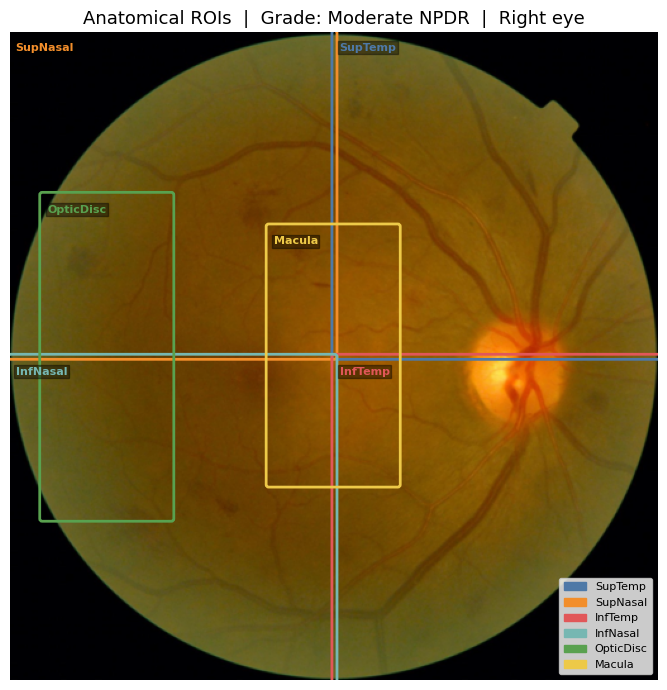


Training...
  Ep   1/50 | loss=1.4891 | val_acc=0.6906 | val_f1=0.5300 | 61s | session=0.04h
  Ep   2/50 | loss=1.0859 | val_acc=0.7671 | val_f1=0.6814 | 63s | session=0.05h
  Ep   3/50 | loss=0.9331 | val_acc=0.7392 | val_f1=0.6353 | 59s | session=0.07h
  Ep   4/50 | loss=0.8785 | val_acc=0.7851 | val_f1=0.7122 | 60s | session=0.09h
  Ep   5/50 | loss=0.8066 | val_acc=0.8121 | val_f1=0.7140 | 62s | session=0.10h
  Ep   6/50 | loss=0.7736 | val_acc=0.7968 | val_f1=0.6984 | 60s | session=0.12h
  Ep   7/50 | loss=0.6910 | val_acc=0.8201 | val_f1=0.7141 | 60s | session=0.14h
  Ep   8/50 | loss=0.6875 | val_acc=0.7806 | val_f1=0.6663 | 62s | session=0.16h
  Ep   9/50 | loss=0.6164 | val_acc=0.8121 | val_f1=0.7173 | 60s | session=0.17h
  Ep  10/50 | loss=0.5760 | val_acc=0.8067 | val_f1=0.7168 | 60s | session=0.19h
  Ep  11/50 | loss=0.5548 | val_acc=0.8372 | val_f1=0.7369 | 61s | session=0.21h
  Ep  12/50 | loss=0.5129 | val_acc=0.8121 | val_f1=0.7215 | 62s | session=0.22h
  Ep  13/50 | l

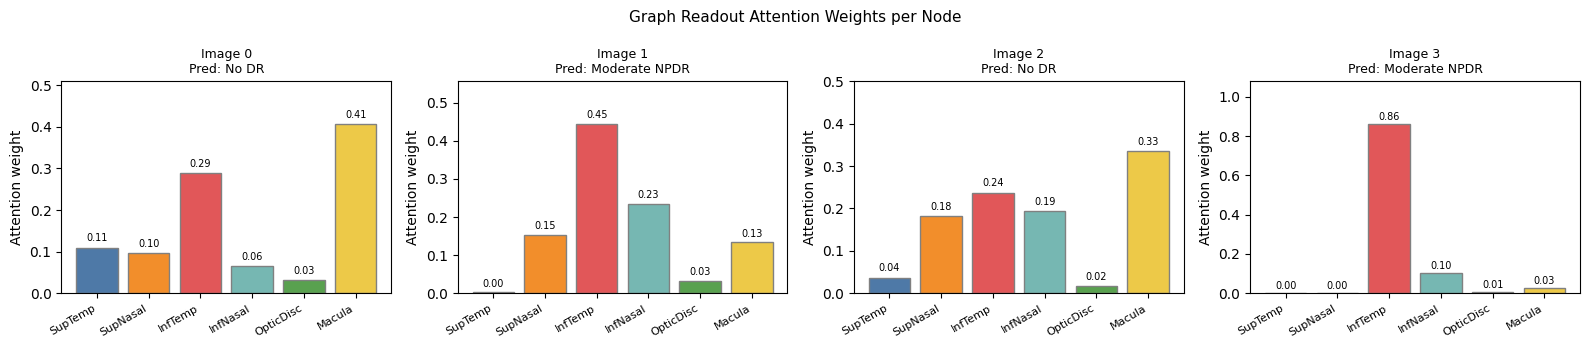


GAT model freed from GPU.


In [14]:
# Task 1B — CFP DR Grading: Anatomical Quadrant GAT (Phase 1)

print('=' * 60)
print('TASK 1B: CFP DR Grading — Anatomical Quadrant GAT (Phase 1)')
print(f'Session: {hours_elapsed():.2f}h')
print('=' * 60)

# ── 0. Ensure `parts` contains Path objects (guard against kernel state loss) ──
parts = [Path(p) if isinstance(p, str) else p for p in parts]
assert all(p.exists() for p in parts), (
    'One or more zip parts are missing. Re-run Cell 2 to re-locate them.'
)
print(f'  Zip parts OK: {len(parts)} parts')

# ── 1. Extract CFP modality if not already done ───────────────────────────
if 'CFP_DIR' not in globals() or CFP_DIR is None or not Path(str(CFP_DIR)).exists():
    print('Extracting CFP modality...')
    CFP_DIR = extract_modality('MMRDR-CFP')
else:
    print(f'CFP already extracted — skipping.')
print(f'  CFP_DIR = {CFP_DIR}')

# ── 2. CSV splits ─────────────────────────────────────────────────────────
print('\nLoading CSV splits...')
cfp_train, cfp_val, cfp_test = load_csv_splits(CFP_DIR, 'FP.csv')

# ── 3. GAT DataLoaders ────────────────────────────────────────────────────
print('Building GAT DataLoaders...')
tr_gat, vl_gat, ts_gat = make_loaders_gat(cfp_train, cfp_val, cfp_test, CFP_DIR)
print(f'  Train: {len(tr_gat)} batches | Val: {len(vl_gat)} | Test: {len(ts_gat)}')

# ── 4. Class weights ──────────────────────────────────────────────────────
class_weights = compute_class_weights(cfp_train, n_classes=5, label_col='grade')
print('  Class weights (grade 0-4):',
      [f'{w:.3f}' for w in class_weights.cpu().tolist()])

# ── 5. Build model ────────────────────────────────────────────────────────
print('\nBuilding RetinalGATClassifier...')
gat_model = build_gat_model(
    n_classes=5, proj_dim=256, n_heads=4,
    n_gat_layers=2, dropout=0.1, aux_weight=0.3,
)
print_model_summary(gat_model)

# ── 6. Visualise ROI regions on one sample ────────────────────────────────
print('\nVisualising anatomical ROI regions on a sample image...')
_sample_ds = MMRDRGradingDatasetGAT(cfp_train.head(1), CFP_DIR, val_test_transform)
_sample_img, _sample_lr, _sample_lbl = _sample_ds[0]
visualize_roi_regions(
    _sample_img, lr=_sample_lr,
    title=(f'Anatomical ROIs  |  Grade: {DR_GRADE_NAMES[_sample_lbl]}'
           f'  |  {"Right" if _sample_lr == 1 else "Left"} eye'),
)

# ── 7. Train ──────────────────────────────────────────────────────────────
if not session_ok(buffer_hrs=1.0):
    print('Session limit approaching — skipping GAT training.')
else:
    print('\nTraining...')
    gat_ckpt = train_task_gat(
        gat_model, tr_gat, vl_gat,
        task_name='cfp_grading_gat',
        class_weights=class_weights,
        aux_weight=0.3,
    )

    # ── 8. Load best checkpoint ───────────────────────────────────────────
    print('\nLoading best checkpoint...')
    load_gat_checkpoint(gat_model, gat_ckpt)

    # ── 9. Evaluate on test set ───────────────────────────────────────────
    print('Evaluating on test set...')
    acc_gat, f1_gat, test_attn = evaluate_gat(gat_model, ts_gat)
    log_results('CFP_Grading_GAT', acc_gat, f1_gat,
                paper_acc=0.823, paper_f1=0.702)

    # ── 10. Comparison with baseline ──────────────────────────────────────
    print()
    baseline = RESULTS.get('CFP_Grading', {})
    if baseline:
        print(f'  ResNet-50 baseline : acc={baseline["acc"]:.4f}  f1={baseline["f1"]:.4f}')
    print(f'  Quadrant GAT       : acc={acc_gat:.4f}  f1={f1_gat:.4f}')
    if baseline:
        print(f'  Delta              : acc={acc_gat - baseline["acc"]:+.4f}'
              f'  f1={f1_gat - baseline["f1"]:+.4f}')

    # ── 11. Attention visualisation ───────────────────────────────────────
    print('\nVisualising node attention weights on test samples...')
    _vis_imgs, _vis_lr, _vis_lbl = next(iter(ts_gat))
    _vis_imgs = _vis_imgs.to(DEVICE)
    _vis_lr   = _vis_lr.to(DEVICE)
    with torch.no_grad():
        _vis_logits, _, _vis_attn = gat_model(_vis_imgs, _vis_lr)
    _vis_preds = _vis_logits.argmax(dim=1).cpu().numpy()
    visualize_attention(
        _vis_attn[:4].cpu(),
        grade_preds=_vis_preds[:4],
        grade_names=DR_GRADE_NAMES,
        max_show=4,
    )

    # ── 12. Clean up ──────────────────────────────────────────────────────
    _cleanup_gat(gat_model)
    print('\nGAT model freed from GPU.')

## Cell 7D — UWF Peripheral Anatomical GAT (Phase 2)
Ultra-Widefield specific redesign: concentric ring topology, peripheral distortion correction, uncertainty nodes.

In [15]:
# Cell 7D — UWF Peripheral Anatomical GAT (Phase 2)
#
# ══════════════════════════════════════════════════════════════════════════════
# DESIGN RATIONALE
# ══════════════════════════════════════════════════════════════════════════════
#
# UWF differs from CFP in three clinically critical ways:
#
#   1. FIELD OF VIEW:  UWF captures 200° vs CFP's 45°–60°.
#      → Peripheral retina (zones 2-3) is entirely absent from CFP.
#      → Far-peripheral lesions (zone 3) are key predictors of PDR conversion.
#
#   2. LESION DISTRIBUTION:  DR severity in UWF correlates with *spread*.
#      Predominantly peripheral lesions shift grading by ≥1 level (DRCR.net).
#      → Graph must encode radial distribution, not just local pooling.
#
#   3. IMAGING ARTEFACTS:  UWF has dark borders (elliptical mask), peripheral
#      distortion (polar projection), uneven illumination (brighter centre),
#      and eyelash/lid artefacts at the periphery.
#      → Need artefact-awareness and confidence-gated reasoning.
#
# ══════════════════════════════════════════════════════════════════════════════
# GRAPH ARCHITECTURE
# ══════════════════════════════════════════════════════════════════════════════
#
#  Node hierarchy (17 nodes total):
#
#   RING 0 — Central retina (2 × 2 quadrant grid, 0.0–0.35 radius frac)
#     0  CentSup   central superior
#     1  CentInf   central inferior
#     2  CentNasal central nasal
#     3  CentTemp  central temporal
#
#   RING 1 — Mid-peripheral (4 sectors, 0.35–0.65 radius frac)
#     4  MidSup    mid superior
#     5  MidInf    mid inferior
#     6  MidNasal  mid nasal
#     7  MidTemp   mid temporal
#
#   RING 2 — Far-peripheral (4 sectors, 0.65–0.90 radius frac)
#     8  FarSup    far superior
#     9  FarInf    far inferior
#    10  FarNasal  far nasal
#    11  FarTemp   far temporal
#
#   ANATOMICAL LANDMARKS (laterality-corrected)
#    12  OpticDisc  (RING 0 region, nasal side)
#    13  Macula     (RING 0 region, temporal side)
#
#   GLOBAL / META NODES
#    14  GlobalContext  — graph-level disease burden aggregator
#    15  UncertaintyNode — receives activations from high-noise peripheral zones;
#                          down-weights unreliable evidence
#    16  HealthyRef    — reference node initialised from low-activation regions;
#                         helps calibrate relative pathology signal
#
# TOPOLOGY (directed, with self-loops):
#   • Intra-ring:   all pairs within each ring (ring-level context)
#   • Radial:       each node → its sector neighbour one ring outward/inward
#                   (centre-to-periphery disease propagation)
#   • Landmark:     OpticDisc/Macula ↔ all Ring-0 nodes
#   • Global:       GlobalContext ← all anatomical nodes (fan-in aggregator)
#                   GlobalContext → all anatomical nodes (global broadcast)
#   • Uncertainty:  UncertaintyNode ← Ring-2 far-peripheral nodes
#                   UncertaintyNode → GlobalContext (uncertainty signal injection)
#   • HealthyRef:   HealthyRef ← Ring-0 (anchored to presumably more reliable
#                   central activations; less artefact contamination)
#                   HealthyRef → GlobalContext
#
# PERIPHERAL CONFIDENCE MECHANISM:
#   For each Ring-2 node, a scalar confidence score c_i ∈ (0,1] is estimated
#   from the activation magnitude relative to the ring mean.  Edge weights from
#   Ring-2 nodes to GlobalContext are multiplied by c_i before attention softmax,
#   preventing high-artefact peripheral nodes from corrupting the global embedding.
#
# ══════════════════════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
import torch.nn.functional as F


# ── 0. Node registry ──────────────────────────────────────────────────────────

UWF_NODE_NAMES = [
    # Ring 0 — central  (0-3)
    'CentSup', 'CentInf', 'CentNasal', 'CentTemp',
    # Ring 1 — mid-peripheral  (4-7)
    'MidSup', 'MidInf', 'MidNasal', 'MidTemp',
    # Ring 2 — far-peripheral  (8-11)
    'FarSup', 'FarInf', 'FarNasal', 'FarTemp',
    # Anatomical landmarks  (12-13)
    'OpticDisc', 'Macula',
    # Global / meta  (14-16)
    'GlobalContext', 'UncertaintyNode', 'HealthyRef',
]

UWF_N_NODES  = len(UWF_NODE_NAMES)   # 17

# Ring membership for topology construction
_UWF_RING0     = list(range(0, 4))    # central
_UWF_RING1     = list(range(4, 8))    # mid-peripheral
_UWF_RING2     = list(range(8, 12))   # far-peripheral
_UWF_LANDMARKS = [12, 13]             # OpticDisc, Macula
_UWF_GLOBAL    = 14
_UWF_UNCERT    = 15
_UWF_HEALTHY   = 16

# Sector ordering within each ring: Sup, Inf, Nasal, Temp
# → sectors 0-3 in Ring-0 map to sectors 0-3 in Ring-1 and Ring-2
# Used to establish radial (centre-out) edges
_SECTOR_COUNT  = 4


# ── 1. UWF ROI coordinate system ─────────────────────────────────────────────
#
# UWF images have an elliptical illuminated region with dark borders.
# Coordinates are defined as fractions of the feature-map spatial dimensions
# (H=W=16 for 512px / stride-32 backbone).
#
# Radial rings:
#   Ring 0 (central)        : 0.00–0.35 of half-image-width from centre
#   Ring 1 (mid-peripheral) : 0.35–0.65
#   Ring 2 (far-peripheral) : 0.65–0.90   (beyond 0.90 = typical dark border)
#
# Each ring is divided into 4 cardinal sectors (Sup/Inf/Nasal/Temp).
# The actual bounding box for each sector is computed analytically below.
#
# For UWF the illuminated field is approximately circular, centred at (0.5, 0.5)
# in fractional coordinates.
#
# LATERALITY:
#   Same convention as CFP (lr==1 right eye, lr==0 left eye).
#   Nasal/Temporal columns are swapped for left eyes.
#   Ring radii are symmetric so only nasal/temp sector bboxes change.

def _uwf_sector_bbox(ring_r_inner, ring_r_outer, sector, right_eye=True):
    """
    Compute (r0f, r1f, c0f, c1f) bounding box for one ring-sector in UWF.

    Args:
        ring_r_inner : inner radius fraction (of half-width)
        ring_r_outer : outer radius fraction (of half-width)
        sector       : 0=Sup, 1=Inf, 2=Nasal, 3=Temp
        right_eye    : if False, swap Nasal<->Temp columns

    Returns:
        (r0f, r1f, c0f, c1f) fractions of full image H and W
    """
    cx, cy = 0.5, 0.5  # image centre fractions

    if sector == 0:   # Superior  -> upper half
        r0f = cy - ring_r_outer
        r1f = cy - ring_r_inner
        c0f = cx - ring_r_outer
        c1f = cx + ring_r_outer
    elif sector == 1:  # Inferior  -> lower half
        r0f = cy + ring_r_inner
        r1f = cy + ring_r_outer
        c0f = cx - ring_r_outer
        c1f = cx + ring_r_outer
    elif sector == 2:  # Nasal
        # Right eye: nasal = left side of image
        # Left  eye: nasal = right side of image
        r0f = cy - ring_r_outer
        r1f = cy + ring_r_outer
        if right_eye:
            c0f = cx - ring_r_outer
            c1f = cx - ring_r_inner
        else:
            c0f = cx + ring_r_inner
            c1f = cx + ring_r_outer
    else:              # Temporal (sector == 3)
        r0f = cy - ring_r_outer
        r1f = cy + ring_r_outer
        if right_eye:
            c0f = cx + ring_r_inner
            c1f = cx + ring_r_outer
        else:
            c0f = cx - ring_r_outer
            c1f = cx - ring_r_inner

    # FIX: clamp start coords to [0, 1-_MIN_SPAN] so there is always room
    # for at least _MIN_SPAN above them. Previously the cap was hardcoded
    # to 0.98, but Ring-2 inferior sectors produce r0f = 0.5+0.65 = 1.15
    # → clamped to 0.98, r1f = 0.5+0.90 = 1.40 → clamped to 1.0, giving
    # a valid fraction pair (0.98, 1.0) that collapses to a single pixel
    # row at small feature-map sizes (H=16: round(0.98*16)=16=H → r0==r1).
    _MIN_SPAN = 0.02
    r0f = max(0.0, min(r0f, 1.0 - _MIN_SPAN))   # FIX: cap was 0.98 (too tight)
    r1f = max(r0f + _MIN_SPAN, min(r1f, 1.0))
    c0f = max(0.0, min(c0f, 1.0 - _MIN_SPAN))   # FIX: cap was 0.98 (too tight)
    c1f = max(c0f + _MIN_SPAN, min(c1f, 1.0))
    return r0f, r1f, c0f, c1f


# Ring radii (fraction of half-image-width = 0.5 full width)
_UWF_RING_RADII = [
    (0.00, 0.35),   # Ring 0  central
    (0.35, 0.65),   # Ring 1  mid-peripheral
    (0.65, 0.90),   # Ring 2  far-peripheral
]

# Optic disc and macula in UWF for right eye
# Disc: central-nasal, ~12% from image centre
# Macula: at image centre (fovea is centred in UWF)
_UWF_DISC_R   = (0.35, 0.65, 0.20, 0.40)   # ring-0 nasal region
_UWF_MACULA_R = (0.35, 0.65, 0.40, 0.60)   # centre


def _build_uwf_roi_coords(right_eye=True):
    """
    Return list of 17 (r0f, r1f, c0f, c1f) ROI coords matching UWF_NODE_NAMES order.
    """
    coords = []
    for ring_idx, (r_inner, r_outer) in enumerate(_UWF_RING_RADII):
        for sector in range(_SECTOR_COUNT):
            coords.append(_uwf_sector_bbox(r_inner, r_outer, sector, right_eye))
    # Landmarks
    if right_eye:
        coords.append(_UWF_DISC_R)
        coords.append(_UWF_MACULA_R)
    else:
        r0, r1, c0, c1 = _UWF_DISC_R
        coords.append((r0, r1, 1.0 - c1, 1.0 - c0))
        coords.append(_UWF_MACULA_R)
    # Global / meta nodes: use full-image bbox (average-pooled globally)
    coords.append((0.05, 0.95, 0.05, 0.95))  # GlobalContext
    coords.append((0.65, 0.95, 0.05, 0.95))  # UncertaintyNode — peripheral band
    coords.append((0.25, 0.75, 0.25, 0.75))  # HealthyRef — central safe zone
    return coords

# Precompute for both lateralities
_UWF_COORDS_RIGHT = _build_uwf_roi_coords(right_eye=True)
_UWF_COORDS_LEFT  = _build_uwf_roi_coords(right_eye=False)


# ── 2. UWF Adjacency matrix ───────────────────────────────────────────────────

def _build_uwf_adjacency():
    """
    Construct UWF graph edge-index (2, E) with self-loops.

    Topology design (see module docstring for full rationale):
      A. Intra-ring edges (all same-ring pairs, bidirectional)
      B. Radial edges (same sector, adjacent rings, bidirectional)
      C. Landmark <-> Ring-0 edges (bidirectional)
      D. GlobalContext <- all anatomical nodes (fan-in)
         GlobalContext -> all anatomical nodes (broadcast)
      E. UncertaintyNode <- Ring-2 far-peripheral nodes
         UncertaintyNode -> GlobalContext
      F. HealthyRef <- Ring-0 (central anchor)
         HealthyRef -> GlobalContext
      G. Self-loops for all nodes (prevents degenerate softmax)
    """
    edges = set()

    def add_bidir(i, j):
        edges.add((i, j))
        edges.add((j, i))

    # A. Intra-ring
    for ring_nodes in [_UWF_RING0, _UWF_RING1, _UWF_RING2]:
        for i in ring_nodes:
            for j in ring_nodes:
                if i != j:
                    edges.add((i, j))

    # B. Radial: sector k of ring r -> sector k of ring r+1
    rings = [_UWF_RING0, _UWF_RING1, _UWF_RING2]
    for r in range(len(rings) - 1):
        for s in range(_SECTOR_COUNT):
            add_bidir(rings[r][s], rings[r + 1][s])

    # C. Landmarks <-> Ring-0
    for lm in _UWF_LANDMARKS:
        for n in _UWF_RING0:
            add_bidir(lm, n)

    # D. GlobalContext <-> all anatomical nodes (12-13 + 0-11)
    anatomical = list(range(14))  # 0..13
    for n in anatomical:
        add_bidir(_UWF_GLOBAL, n)

    # E. UncertaintyNode <- Ring-2; UncertaintyNode -> GlobalContext
    for n in _UWF_RING2:
        edges.add((n, _UWF_UNCERT))   # fan-in only (peripheral -> uncertainty)
    add_bidir(_UWF_UNCERT, _UWF_GLOBAL)

    # F. HealthyRef <- Ring-0; HealthyRef -> GlobalContext
    for n in _UWF_RING0:
        edges.add((n, _UWF_HEALTHY))  # fan-in only (central -> healthy-ref)
    add_bidir(_UWF_HEALTHY, _UWF_GLOBAL)

    # G. Self-loops — critical for stable attention
    for i in range(UWF_N_NODES):
        edges.add((i, i))

    src, dst = zip(*sorted(edges))
    ei = torch.tensor([list(src), list(dst)], dtype=torch.long)
    return ei

_UWF_EDGE_INDEX_CPU = _build_uwf_adjacency()


# ── 3. Peripheral confidence estimator ───────────────────────────────────────
#
# Lightweight, parameter-free.
# For each Ring-2 node, confidence = sigmoid( (||f_i|| / (ring_mean_norm + ε)) - 1 )
# Intuition:
#   - Nodes with activation near or above ring mean -> confidence ≈ 0.5–0.9
#   - Nodes with near-zero activation (dark border / artefact) -> confidence ≈ 0.1–0.3
# The confidence scores are used as edge weight multipliers before GATLayer scatter.

def _compute_peripheral_confidence(node_feats_proj):
    """
    Estimate per-node confidence for Ring-2 (far-peripheral) nodes.

    Args:
        node_feats_proj : (B, N_NODES, D) — projected node features

    Returns:
        conf_ring2 : (B, 4)  confidence in [0,1] for Ring-2 nodes (indices 8-11)
    """
    ring2_feats = node_feats_proj[:, _UWF_RING2, :]           # (B, 4, D)
    norms       = ring2_feats.norm(dim=-1)                     # (B, 4)
    ring_mean   = norms.mean(dim=-1, keepdim=True)             # (B, 1)
    ratio       = norms / (ring_mean + 1e-6)                   # (B, 4)
    conf        = torch.sigmoid(ratio - 1.0)                   # (B, 4) in (0,1)
    return conf                                                 # (B, 4)


# ── 4. UWF peripheral distortion correction ──────────────────────────────────
#
# UWF images have reduced signal-to-noise and geometric distortion in the
# far periphery due to the wide-angle optics.  We apply a lightweight
# learned per-ring feature normalisation (similar to instance norm per ring)
# before graph construction, so that peripheral node features are on a
# comparable scale to central ones.

class UWFRingNorm(nn.Module):
    """
    Learnable ring-wise layer normalisation.

    Applies a separate LayerNorm to each ring group, then re-stacks.
    This allows the model to independently normalise central vs peripheral
    feature distributions, countering UWF's uneven illumination.

    No parameters are shared across rings -> ring-specific scale/bias.
    """
    def __init__(self, embed_dim):
        super().__init__()
        # One LayerNorm per ring + one for landmarks + one for meta nodes
        self.ring_norms = nn.ModuleList([
            nn.LayerNorm(embed_dim) for _ in range(5)   # ring0,1,2, landmarks, meta
        ])

    def forward(self, node_feats):
        """
        Args:
            node_feats : (B, 17, D)

        Returns:
            out : (B, 17, D)
        """
        groups = [
            (self.ring_norms[0], _UWF_RING0),
            (self.ring_norms[1], _UWF_RING1),
            (self.ring_norms[2], _UWF_RING2),
            (self.ring_norms[3], _UWF_LANDMARKS),
            (self.ring_norms[4], [_UWF_GLOBAL, _UWF_UNCERT, _UWF_HEALTHY]),
        ]
        out = node_feats.clone()
        for norm_layer, indices in groups:
            # FIX: under AMP, node_feats is float16 but LayerNorm always returns
            # float32. Cast the norm output back to the input dtype before the
            # index-put assignment, otherwise RuntimeError: dtype mismatch (Half
            # destination, Float source).
            out[:, indices, :] = norm_layer(node_feats[:, indices, :]).to(node_feats.dtype)
        return out


# ── 5. UWF Graph Builder ──────────────────────────────────────────────────────

class UWFGraphBuilder(nn.Module):
    """
    Builds the 17-node UWF peripheral retinal graph from a spatial feature map.

    Steps:
        1. Average-pool each of the 17 ROI bounding boxes (laterality-aware)
        2. Apply UWFRingNorm for ring-wise feature normalisation
        3. Estimate Ring-2 peripheral confidence scores

    Returns:
        node_feats  : (B, 17, C)  ring-normalised node features
        ring2_conf  : (B, 4)      confidence scores for far-peripheral nodes

    No learnable parameters in ROI pooling — the backbone learns what to extract.
    UWFRingNorm contains ~5x2D learnable scale/bias vectors (tiny).
    """

    def __init__(self, backbone_dim):
        super().__init__()
        self.ring_norm = UWFRingNorm(backbone_dim)

    def forward(self, feat_map, lr_flags):
        """
        Args:
            feat_map : (B, C, H, W)
            lr_flags : (B,) LongTensor  1=right, 0=left

        Returns:
            node_feats : (B, 17, C)
            ring2_conf : (B, 4)       BEFORE projection (used for logging)
        """
        B, C, H, W = feat_map.shape
        node_feats = torch.zeros(B, UWF_N_NODES, C,
                                 device=feat_map.device, dtype=feat_map.dtype)

        for b in range(B):
            coords = (_UWF_COORDS_RIGHT if lr_flags[b].item() == 1
                      else _UWF_COORDS_LEFT)
            fm_b = feat_map[b:b+1]   # (1, C, H, W) for _roi_pool
            for n_idx, (r0f, r1f, c0f, c1f) in enumerate(coords):
                node_feats[b, n_idx, :] = _roi_pool(fm_b, r0f, r1f, c0f, c1f)[0]

        # Ring-normalise BEFORE computing confidence
        node_feats = self.ring_norm(node_feats)

        # Confidence on raw (pre-projection) features
        ring2_conf = _compute_peripheral_confidence(node_feats)

        return node_feats, ring2_conf   # (B, 17, C), (B, 4)


# ── 6. Confidence-Gated GATLayer ─────────────────────────────────────────────
#
# Extension of GATLayer that supports an optional edge-confidence mask.
# When confidence scores are provided, edges FROM low-confidence nodes
# have their attention logits penalised before softmax:
#
#   e_ij_gated = e_ij + log(conf_i)   (adds log-domain penalty)
#
# This is equivalent to multiplying the attention weight by conf_i in the
# pre-softmax linear space, without breaking softmax normalisation.
#
# For most edges confidence=1.0 (no penalty).  Only Ring-2 -> GlobalContext and
# Ring-2 -> UncertaintyNode edges carry sub-unity confidence.

class ConfidenceGatedGATLayer(nn.Module):
    """
    Multi-head GAT layer with optional confidence-gated edge attention.

    Same mathematics as GATLayer (Phase 1) with one addition:
        e_ij <- e_ij + log(conf_i + ε)   when conf tensor is not None

    Args:
        in_features   : input dim per node
        out_per_head  : output dim per head
        n_heads       : number of attention heads
        dropout       : attention dropout
        residual      : if True, add skip connection
    """

    def __init__(self, in_features, out_per_head, n_heads=4,
                 dropout=0.1, residual=True):
        super().__init__()
        self.n_heads      = n_heads
        self.out_per_head = out_per_head
        self.out_total    = out_per_head * n_heads
        self.residual     = residual

        self.W_heads    = nn.ModuleList([
            nn.Linear(in_features, out_per_head, bias=False) for _ in range(n_heads)
        ])
        self.attn_heads = nn.ModuleList([
            nn.Linear(2 * out_per_head, 1, bias=False) for _ in range(n_heads)
        ])
        self.leaky   = nn.LeakyReLU(negative_slope=0.2)
        self.dropout = nn.Dropout(dropout)
        self.norm    = nn.LayerNorm(self.out_total)

        if residual:
            self.res_proj = (
                nn.Linear(in_features, self.out_total, bias=False)
                if in_features != self.out_total else nn.Identity()
            )

        for attn in self.attn_heads:
            nn.init.normal_(attn.weight, std=0.01)

    def forward(self, x, edge_index, node_conf=None):
        """
        Args:
            x          : (B, N, in_features)
            edge_index : (2, E)
            node_conf  : (B, N) optional per-node confidence in (0,1]
                         (only the Ring-2 nodes have sub-unity conf;
                          pass None to disable confidence gating)

        Returns:
            out : (B, N, out_total)
        """
        B, N, _ = x.shape
        src, dst = edge_index[0], edge_index[1]   # (E,)

        # Build log-confidence penalty for source nodes: (B, E)
        if node_conf is not None:
            log_conf_src = torch.log(node_conf[:, src] + 1e-6)   # (B, E)
        else:
            log_conf_src = None

        head_outputs = []
        for k in range(self.n_heads):
            h = self.W_heads[k](x)                           # (B, N, out_per_head)
            h_src     = h[:, src, :]                         # (B, E, D)
            h_dst     = h[:, dst, :]                         # (B, E, D)
            edge_feat = torch.cat([h_src, h_dst], dim=-1)   # (B, E, 2D)
            e         = self.leaky(self.attn_heads[k](edge_feat)).squeeze(-1)  # (B, E)

            # Confidence gating: penalise low-confidence source edges
            if log_conf_src is not None:
                e = e + log_conf_src   # (B, E)  additive in log-space

            attn_mat = torch.full((B, N, N), float('-inf'),
                                  device=x.device, dtype=x.dtype)
            attn_mat[:, dst, src] = e
            attn_mat = torch.softmax(attn_mat, dim=-1)
            attn_mat = torch.nan_to_num(attn_mat, nan=0.0, posinf=0.0, neginf=0.0)
            attn_mat = self.dropout(attn_mat)

            agg = torch.bmm(attn_mat, h)   # (B, N, out_per_head)
            head_outputs.append(agg)

        out = torch.cat(head_outputs, dim=-1)   # (B, N, out_total)

        if self.residual:
            out = out + self.res_proj(x)
        out = self.norm(out)
        out = F.elu(out)

        if out.isnan().any():
            out = torch.nan_to_num(out, nan=0.0)

        return out


# ── 7. UWF Graph Readout ──────────────────────────────────────────────────────
#
# Two-stage readout for UWF:
#   Stage 1: Per-ring attention pooling (creates 3 ring embeddings + global node)
#   Stage 2: Ring-level attention pooling -> final graph embedding
#
# Rationale: UWF grading depends on DISTRIBUTION across rings, not just local
# pathology.  A 2-stage readout explicitly computes ring-level disease burden
# before global aggregation, making the peripheral spread reasoning interpretable.

class UWFGraphReadout(nn.Module):
    """
    Two-stage ring-aware graph readout.

    Stage 1: For each ring, compute a ring embedding via attention pooling
             over the ring's nodes.
    Stage 2: Aggregate ring embeddings + GlobalContext node via attention.

    Output: (B, embed_dim) graph embedding
    Attention: returns ring-level weights for interpretability.
    """

    def __init__(self, embed_dim):
        super().__init__()
        # Separate query per ring (4 rings: 0,1,2 + global-meta group)
        n_queries = 4
        self.ring_queries  = nn.Parameter(torch.empty(n_queries, embed_dim))
        self.global_query  = nn.Parameter(torch.empty(embed_dim))
        # Ring groups for Stage 1
        self._ring_groups  = [_UWF_RING0, _UWF_RING1, _UWF_RING2,
                               [_UWF_GLOBAL, _UWF_UNCERT, _UWF_HEALTHY]]

        # Projection to output dim (same — identity compatible)
        self.out_proj = nn.Linear(embed_dim * n_queries, embed_dim)

        for p in [self.ring_queries, self.global_query]:
            nn.init.kaiming_uniform_(p.unsqueeze(0), a=0.2)
        nn.init.xavier_uniform_(self.out_proj.weight)

    def forward(self, x):
        """
        Args:
            x : (B, 17, embed_dim)

        Returns:
            graph_embed  : (B, embed_dim)
            ring_attn    : list of 4 (B, n_ring_nodes) weight tensors
                           [ring0_attn, ring1_attn, ring2_attn, meta_attn]
        """
        ring_embeds = []
        ring_attns  = []

        for qi, group_indices in enumerate(self._ring_groups):
            group_feats = x[:, group_indices, :]           # (B, k, D)
            q           = self.ring_queries[qi]             # (D,)
            scores      = torch.matmul(group_feats, q)     # (B, k)
            attn        = torch.softmax(scores, dim=-1)    # (B, k)
            embed       = (group_feats * attn.unsqueeze(-1)).sum(1)  # (B, D)
            ring_embeds.append(embed)
            ring_attns.append(attn)

        # Stage 2: aggregate ring embeddings
        cat_embeds  = torch.cat(ring_embeds, dim=-1)    # (B, 4D)
        graph_embed = self.out_proj(cat_embeds)         # (B, D)
        return graph_embed, ring_attns


# ── 8. UWF Focal Loss + Weighted CE ──────────────────────────────────────────

class FocalLoss(nn.Module):
    """
    Focal loss for DR grading (class-imbalanced UWF data).
    FL(p_t) = -alpha_t (1 - p_t)^gamma log(p_t)

    Args:
        alpha  : per-class weight tensor (shape [n_classes]) or None
        gamma  : focusing parameter (2.0 is standard)
        reduction: 'mean' | 'sum' | 'none'
    """
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.gamma     = gamma
        self.reduction = reduction
        self.register_buffer('alpha', alpha)   # may be None

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce)
        fl = (1 - pt) ** self.gamma * ce
        if self.reduction == 'mean':   return fl.mean()
        if self.reduction == 'sum':    return fl.sum()
        return fl


def get_uwf_loss(train_df_or_weights, use_focal=True, gamma=2.0, n_classes=5):
    """
    Build loss function for UWF DR grading.

    Args:
        train_df_or_weights : either a training DataFrame (class weights are computed)
                              or a pre-computed FloatTensor of shape (n_classes,)
        use_focal           : if True, use FocalLoss; else WeightedCE
        gamma               : focal loss gamma (ignored if use_focal=False)

    Returns:
        loss_fn : nn.Module
    """
    if isinstance(train_df_or_weights, torch.Tensor):
        weights = train_df_or_weights.to(DEVICE)
    else:
        weights = compute_class_weights(train_df_or_weights, n_classes=n_classes)

    if use_focal:
        return FocalLoss(alpha=weights, gamma=gamma).to(DEVICE)
    else:
        return nn.CrossEntropyLoss(weight=weights).to(DEVICE)


# ── 9. UWF Retinal GAT Classifier ─────────────────────────────────────────────

class UWFRetinalGATClassifier(nn.Module):
    """
    Phase-2 UWF DR Grading Model:
      ResNet-50 backbone -> UWFGraphBuilder -> 17-node Peripheral GAT -> 2-stage Readout

    Call signature:
        logits, aux_logits, ring_attns, ring2_conf = model(images, lr_flags)

    Args:
        pretrained_weights_path : path to resnet50 .pth ImageNet weights
        n_classes    : DR grading classes (default 5)
        proj_dim     : node embedding dimension (default 256; must be divisible by n_heads)
        n_heads      : GAT attention heads (default 4)
        n_gat_layers : stacked ConfidenceGatedGATLayers (default 3; UWF is harder)
        dropout      : attention dropout (default 0.15; slightly higher for UWF noise)
        aux_weight   : auxiliary GAP head weight (default 0.3)

    Returns:
        logits       : (B, n_classes)  DR grade logits
        aux_logits   : (B, n_classes) or None
        ring_attns   : list of 4 (B, k) ring-level attention weight tensors
        ring2_conf   : (B, 4)  far-peripheral node confidence scores

    Architecture note:
        3 GAT layers instead of 2 reflects UWF's higher complexity:
        layer 1 = local ring context
        layer 2 = radial propagation (centre->periphery)
        layer 3 = global integration + uncertainty resolution
    """

    def __init__(self, pretrained_weights_path, n_classes=5,
                 proj_dim=256, n_heads=4, n_gat_layers=3,
                 dropout=0.15, aux_weight=0.3):
        super().__init__()
        assert proj_dim % n_heads == 0, (
            f"proj_dim ({proj_dim}) must be divisible by n_heads ({n_heads})"
        )
        backbone_dim = 2048
        out_per_head = proj_dim // n_heads
        self.aux_weight = aux_weight

        self.arch_cfg = dict(
            n_classes=n_classes, proj_dim=proj_dim,
            n_heads=n_heads, n_gat_layers=n_gat_layers,
            dropout=dropout, aux_weight=aux_weight,
            n_nodes=UWF_N_NODES, model_type='UWFRetinalGATClassifier',
        )

        # ── Backbone ───────────────────────────────────────────────────────
        self.backbone = ResNet50Backbone(pretrained_weights_path)

        # ── UWF Graph Builder (ROI pool + ring norm + confidence) ──────────
        self.graph_builder = UWFGraphBuilder(backbone_dim)

        # ── Node projection: 2048 -> proj_dim ──────────────────────────────
        self.node_proj = nn.Sequential(
            nn.Linear(backbone_dim, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.ReLU(inplace=True),
        )

        # Build per-node confidence vector (17-dim, mostly 1.0 except ring2)
        # Stored as a buffer; updated each forward pass from ring2_conf
        self.register_buffer(
            'node_conf_template',
            torch.ones(1, UWF_N_NODES)   # (1, 17)
        )

        # ── Stacked Confidence-Gated GAT layers ────────────────────────────
        gat_layers = []
        for _ in range(n_gat_layers):
            gat_layers.append(
                ConfidenceGatedGATLayer(proj_dim, out_per_head,
                                        n_heads, dropout, residual=True)
            )
        self.gat_layers = nn.ModuleList(gat_layers)

        # ── Two-stage ring-aware readout ────────────────────────────────────
        self.readout = UWFGraphReadout(proj_dim)

        # ── Grading head ───────────────────────────────────────────────────
        self.grading_head = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(proj_dim, n_classes),
        )

        # ── Optional auxiliary GAP head ────────────────────────────────────
        if aux_weight > 0:
            self.aux_head = nn.Sequential(
                nn.Dropout(0.2),
                nn.Linear(backbone_dim, n_classes),
            )
        else:
            self.aux_head = None

        # Edge index buffer
        self.register_buffer('edge_index', _UWF_EDGE_INDEX_CPU.clone())

    def forward(self, images, lr_flags):
        """
        Args:
            images   : (B, 3, H, W)
            lr_flags : (B,) LongTensor   1=right, 0=left

        Returns:
            logits       : (B, n_classes)
            aux_logits   : (B, n_classes) or None
            ring_attns   : list[4] of (B, k) ring attention weights
            ring2_conf   : (B, 4)  peripheral confidence
        """
        # 1. Backbone
        feat_map, gap_feat = self.backbone(images)   # (B,2048,H',W'), (B,2048)

        # 2. UWF graph node features + peripheral confidence
        node_feats_raw, ring2_conf = self.graph_builder(feat_map, lr_flags)
        # node_feats_raw : (B, 17, 2048)
        # ring2_conf     : (B, 4)  per Ring-2 node

        # 3. Project to graph embedding dim
        node_feats = self.node_proj(node_feats_raw)   # (B, 17, proj_dim)

        # 4. Pre-GAT NaN guard
        if node_feats.isnan().any():
            node_feats = torch.nan_to_num(node_feats, nan=0.0)

        # 5. Build full per-node confidence for confidence gating
        #    Only Ring-2 nodes (indices 8-11) carry sub-unity confidence;
        #    all other nodes default to 1.0
        B = node_feats.shape[0]
        node_conf = self.node_conf_template.expand(B, -1).clone()  # (B, 17)
        node_conf[:, _UWF_RING2] = ring2_conf                      # fill ring2

        # 6. Stacked GAT layers
        h = node_feats
        for layer in self.gat_layers:
            h = layer(h, self.edge_index, node_conf=node_conf)   # (B, 17, proj_dim)

        # 7. Two-stage ring readout
        graph_embed, ring_attns = self.readout(h)   # (B, proj_dim), list[4]

        # 8. Heads
        logits     = self.grading_head(graph_embed)
        aux_logits = self.aux_head(gap_feat) if self.aux_head is not None else None

        return logits, aux_logits, ring_attns, ring2_conf


# ── 10. Convenience constructors ──────────────────────────────────────────────

def build_uwf_gat_model(n_classes=5, proj_dim=256, n_heads=4,
                         n_gat_layers=3, dropout=0.15, aux_weight=0.3):
    """Convenience constructor — mirrors build_gat_model interface."""
    model = UWFRetinalGATClassifier(
        pretrained_weights_path=_RESNET50_WEIGHTS,
        n_classes=n_classes, proj_dim=proj_dim,
        n_heads=n_heads, n_gat_layers=n_gat_layers,
        dropout=dropout, aux_weight=aux_weight,
    )
    return model.to(DEVICE)


def save_uwf_gat_checkpoint(model, path, epoch=None, val_acc=None, val_f1=None):
    """Save UWFRetinalGATClassifier checkpoint with architecture metadata."""
    torch.save({
        'state_dict' : model.state_dict(),
        'arch_cfg'   : model.arch_cfg,
        'epoch'      : epoch,
        'val_acc'    : val_acc,
        'val_f1'     : val_f1,
    }, path)


def load_uwf_gat_checkpoint(model, path):
    """Load and validate a UWF GAT checkpoint. Raises on arch mismatch."""
    ckpt    = torch.load(path, map_location=DEVICE, weights_only=False)
    stored  = ckpt.get('arch_cfg', {})
    current = model.arch_cfg
    for key in current:
        if key in stored:
            assert stored[key] == current[key], (
                f"UWF checkpoint arch mismatch '{key}': "
                f"stored={stored[key]}, model={current[key]}"
            )
    model.load_state_dict(ckpt['state_dict'])
    meta = {k: ckpt.get(k) for k in ('epoch', 'val_acc', 'val_f1')}
    print(f"  Loaded UWF checkpoint: epoch={meta['epoch']}, "
          f"val_acc={meta['val_acc']}, val_f1={meta['val_f1']}")
    return meta


def print_uwf_model_summary(model):
    """Print parameter count by component for UWFRetinalGATClassifier."""
    sections = {
        'backbone'      : model.backbone,
        'graph_builder' : model.graph_builder,
        'node_proj'     : model.node_proj,
        'gat_layers'    : model.gat_layers,
        'readout'       : model.readout,
        'grading_head'  : model.grading_head,
    }
    total = 0
    print(f'{"Component":<22} {"Params":>12}  {"Trainable":>12}')
    print('-' * 52)
    for name, mod in sections.items():
        p_all   = sum(p.numel() for p in mod.parameters())
        p_train = sum(p.numel() for p in mod.parameters() if p.requires_grad)
        total  += p_all
        print(f'  {name:<20} {p_all:>12,}  {p_train:>12,}')
    if model.aux_head is not None:
        p = sum(x.numel() for x in model.aux_head.parameters())
        total += p
        print(f'  {"aux_head":<20} {p:>12,}  {p:>12,}')
    print('-' * 52)
    print(f'  {"TOTAL":<20} {total:>12,}')
    print(f'\n  Nodes : {UWF_N_NODES}  {UWF_NODE_NAMES}')
    print(f'  Edges : {_UWF_EDGE_INDEX_CPU.shape[1]} directed edges '
          f'(including {UWF_N_NODES} self-loops)')


# ── 11. Sanity print ──────────────────────────────────────────────────────────
print('UWF Phase-2 GAT architecture defined.')
print(f'  Nodes : {UWF_N_NODES}')
print(f'  Edges : {_UWF_EDGE_INDEX_CPU.shape[1]} directed edges')
print(f'  Ring-0 (central)       : {[UWF_NODE_NAMES[i] for i in _UWF_RING0]}')
print(f'  Ring-1 (mid-peripheral): {[UWF_NODE_NAMES[i] for i in _UWF_RING1]}')
print(f'  Ring-2 (far-peripheral): {[UWF_NODE_NAMES[i] for i in _UWF_RING2]}')
print(f'  Landmarks              : {[UWF_NODE_NAMES[i] for i in _UWF_LANDMARKS]}')
print(f'  Meta nodes             : GlobalContext, UncertaintyNode, HealthyRef')

UWF Phase-2 GAT architecture defined.
  Nodes : 17
  Edges : 125 directed edges
  Ring-0 (central)       : ['CentSup', 'CentInf', 'CentNasal', 'CentTemp']
  Ring-1 (mid-peripheral): ['MidSup', 'MidInf', 'MidNasal', 'MidTemp']
  Ring-2 (far-peripheral): ['FarSup', 'FarInf', 'FarNasal', 'FarTemp']
  Landmarks              : ['OpticDisc', 'Macula']
  Meta nodes             : GlobalContext, UncertaintyNode, HealthyRef


## Cell 7E — UWF Visualisation & Debug Utilities

In [16]:
# Cell 7E — Visualisation & debug utilities for UWF Phase-2 GAT
#
# Functions:
#   visualize_uwf_roi_regions   — draw 17-node ROI boxes on a UWF image
#   visualize_uwf_ring_attention — per-ring attention bar charts (2-stage readout)
#   visualize_uwf_peripheral_conf — Ring-2 confidence heatmap
#   visualize_uwf_graph_topology — NetworkX-style edge diagram of the 17-node graph
#   print_uwf_adjacency          — human-readable edge list
#   debug_uwf_forward            — run one forward pass and report shape/NaN status

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


# Colour scheme: one per node, colour-blind friendly
# Ring 0 (blue), Ring 1 (orange), Ring 2 (red), Landmarks (green/purple), Meta (grey)
_UWF_NODE_COLOURS = (
    ['#4e79a7'] * 4 +    # Ring 0 — blue family
    ['#f28e2b'] * 4 +    # Ring 1 — orange family
    ['#e15759'] * 4 +    # Ring 2 — red family
    ['#59a14f', '#b07aa1'] +  # OpticDisc green, Macula purple
    ['#9c755f', '#bab0ac', '#76b7b2']  # Global (brown), Uncertainty (grey), Healthy (teal)
)

_UWF_RING_COLOURS = {
    'Ring 0 (Central)':    '#4e79a7',
    'Ring 1 (Mid-Periph)': '#f28e2b',
    'Ring 2 (Far-Periph)': '#e15759',
    'Landmarks':           '#59a14f',
    'Meta nodes':          '#9c755f',
}


def visualize_uwf_roi_regions(image_tensor, lr=1,
                               title='UWF Anatomical ROI Regions (17 nodes)'):
    """
    Draw all 17 ROI bounding boxes on a UWF image tensor.

    Args:
        image_tensor : (3, H, W) normalised tensor from dataset
        lr           : 1=right eye, 0=left eye
        title        : figure title
    """
    img_np = _unnorm_image(image_tensor)
    H, W   = img_np.shape[:2]
    coords = _UWF_COORDS_RIGHT if lr == 1 else _UWF_COORDS_LEFT

    fig, ax = plt.subplots(1, 1, figsize=(9, 9))
    ax.imshow(img_np)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

    patches = []
    for n_idx, (r0f, r1f, c0f, c1f) in enumerate(coords):
        x0 = int(c0f * W)
        y0 = int(r0f * H)
        bw = max(3, int((c1f - c0f) * W))
        bh = max(3, int((r1f - r0f) * H))
        colour = _UWF_NODE_COLOURS[n_idx]
        lw     = 2.5 if n_idx >= 14 else 1.5  # meta nodes get thicker border
        style  = 'dashed' if n_idx == 15 else 'solid'  # UncertaintyNode dashed

        rect = mpatches.FancyBboxPatch(
            (x0, y0), bw, bh,
            boxstyle='round,pad=1',
            linewidth=lw, edgecolor=colour, facecolor='none',
            linestyle=style,
        )
        ax.add_patch(rect)

        # Label for non-overlapping readability: only show name for key nodes
        name = UWF_NODE_NAMES[n_idx]
        ax.text(x0 + 2, y0 + 12, name, color=colour, fontsize=6,
                fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.35, pad=1))
        patches.append(mpatches.Patch(color=colour, label=name))

    ax.legend(handles=patches, loc='lower right', fontsize=6,
              framealpha=0.8, ncol=3)
    plt.tight_layout()
    plt.show()


def visualize_uwf_ring_attention(ring_attns_batch, ring2_conf_batch=None,
                                  grade_preds=None, grade_names=None, max_show=4):
    """
    Visualise 2-stage ring attention weights from UWFGraphReadout.

    Args:
        ring_attns_batch : list of 4 tensors, each (B, k)
                           [ring0_attn(B,4), ring1_attn(B,4), ring2_attn(B,4), meta_attn(B,3)]
        ring2_conf_batch : (B, 4) peripheral confidence scores (optional)
        grade_preds      : (B,) predicted grades (optional)
        grade_names      : list of grade name strings (optional)
        max_show         : max number of images to plot
    """
    # Convert to numpy
    attns_np = [a.float().detach().cpu().numpy() for a in ring_attns_batch]
    conf_np  = (ring2_conf_batch.float().detach().cpu().numpy()
                if ring2_conf_batch is not None else None)

    B = attns_np[0].shape[0]
    n_show = min(B, max_show)

    ring_labels = [
        [UWF_NODE_NAMES[i] for i in _UWF_RING0],
        [UWF_NODE_NAMES[i] for i in _UWF_RING1],
        [UWF_NODE_NAMES[i] for i in _UWF_RING2],
        [UWF_NODE_NAMES[i] for i in [_UWF_GLOBAL, _UWF_UNCERT, _UWF_HEALTHY]],
    ]
    ring_names  = ['Ring 0 (Central)', 'Ring 1 (Mid)', 'Ring 2 (Far)', 'Meta']
    ring_cols   = ['#4e79a7', '#f28e2b', '#e15759', '#9c755f']

    for i in range(n_show):
        fig, axes = plt.subplots(1, 4, figsize=(16, 3))
        for ri, (ax, attn, labels, rname, rcol) in enumerate(
                zip(axes, attns_np, ring_labels, ring_names, ring_cols)):
            w = attn[i]
            ax.bar(range(len(labels)), w, color=rcol, edgecolor='grey', alpha=0.8)
            ax.set_xticks(range(len(labels)))
            ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=7)
            ax.set_ylim(0, max(w.max() * 1.3, 0.5))
            ax.set_title(rname, fontsize=9)
            ax.set_ylabel('Attn weight', fontsize=7)
            for xi, wi in enumerate(w):
                ax.text(xi, wi + 0.01, f'{wi:.2f}', ha='center', fontsize=6)

            # Overlay confidence for Ring-2
            if ri == 2 and conf_np is not None:
                ax2 = ax.twinx()
                ax2.plot(range(4), conf_np[i], 'k--o', markersize=4, linewidth=1.2,
                         label='conf')
                ax2.set_ylim(0, 1.2)
                ax2.set_ylabel('Confidence', fontsize=6)
                ax2.legend(fontsize=6)

        ttl = f'Image {i}'
        if grade_preds is not None:
            g     = int(grade_preds[i])
            gname = grade_names[g] if grade_names else str(g)
            ttl  += f'  |  Pred: {gname}'
        fig.suptitle(ttl, fontsize=10)
        plt.tight_layout()
        plt.show()


def visualize_uwf_peripheral_conf(ring2_conf_batch, max_show=6):
    """
    Display Ring-2 peripheral confidence as a simple bar chart per image.

    Args:
        ring2_conf_batch : (B, 4)  tensor or ndarray
    """
    if isinstance(ring2_conf_batch, torch.Tensor):
        conf = ring2_conf_batch.float().detach().cpu().numpy()
    else:
        conf = np.asarray(ring2_conf_batch)

    n_show = min(len(conf), max_show)
    ring2_names = [UWF_NODE_NAMES[i] for i in _UWF_RING2]

    fig, axes = plt.subplots(1, n_show, figsize=(3.5 * n_show, 3), squeeze=False)
    for i in range(n_show):
        ax  = axes[0][i]
        c   = conf[i]
        bars = ax.bar(range(4), c, color='#e15759', edgecolor='grey', alpha=0.85)
        ax.set_xticks(range(4))
        ax.set_xticklabels(ring2_names, rotation=25, ha='right', fontsize=7)
        ax.set_ylim(0, 1.1)
        ax.set_title(f'Image {i}\nPeripheral Confidence', fontsize=8)
        ax.axhline(0.5, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
        for bar, ci in zip(bars, c):
            ax.text(bar.get_x() + bar.get_width()/2, ci + 0.02,
                    f'{ci:.2f}', ha='center', fontsize=6)
    plt.suptitle('Ring-2 Far-Peripheral Node Confidence', fontsize=10)
    plt.tight_layout()
    plt.show()


def visualize_uwf_graph_topology():
    """
    Draw the 17-node UWF graph topology as a radial layout diagram.
    Nodes are positioned in concentric rings; edges are drawn as lines.
    Meta nodes float in the outer fringe.
    """
    try:
        import matplotlib.patheffects as pe
    except ImportError:
        pe = None

    fig, ax = plt.subplots(1, 1, figsize=(11, 11))
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('UWF 17-Node Peripheral Retinal Graph Topology\n'
                 '(Phase 2 — Anatomical + Peripheral + Safety)', fontsize=11)

    # Node positions: concentric rings
    node_pos = {}
    ring_radii_vis = [0.0, 1.8, 3.0, 4.2]  # visual ring radii

    # Rings 0-2 (4 sectors each): evenly spaced at 0°, 90°, 180°, 270°
    # Sector order: Sup=90°, Inf=270°, Nasal=180° (for right eye), Temp=0°
    sector_angles = [90, 270, 180, 0]   # matches Sup, Inf, Nasal, Temp order
    for ring_idx, node_list in enumerate([_UWF_RING0, _UWF_RING1, _UWF_RING2]):
        r = ring_radii_vis[ring_idx + 1]
        for si, ni in enumerate(node_list):
            angle = np.radians(sector_angles[si])
            node_pos[ni] = (r * np.cos(angle), r * np.sin(angle))

    # Landmarks: inside ring-0, offset slightly
    node_pos[12] = (-1.1, 0.3)   # OpticDisc (nasal)
    node_pos[13] = ( 0.0, 0.0)   # Macula (centre)
    # Meta nodes: outside ring-2
    node_pos[14] = ( 5.2,  0.0)  # GlobalContext (right)
    node_pos[15] = ( 4.8,  2.2)  # UncertaintyNode (upper-right)
    node_pos[16] = ( 4.8, -2.2)  # HealthyRef (lower-right)

    # Draw edges (skip self-loops for clarity)
    src_arr, dst_arr = _UWF_EDGE_INDEX_CPU[0].tolist(), _UWF_EDGE_INDEX_CPU[1].tolist()
    drawn = set()
    for s, d in zip(src_arr, dst_arr):
        if s == d:  continue
        key = (min(s,d), max(s,d))
        if key in drawn:  continue
        drawn.add(key)
        xs = [node_pos[s][0], node_pos[d][0]]
        ys = [node_pos[s][1], node_pos[d][1]]
        ax.plot(xs, ys, '-', color='#cccccc', linewidth=0.8, zorder=1, alpha=0.7)

    # Draw nodes
    for ni, name in enumerate(UWF_NODE_NAMES):
        x, y = node_pos[ni]
        col  = _UWF_NODE_COLOURS[ni]
        size = 280 if ni >= 14 else 200
        ax.scatter(x, y, s=size, c=col, zorder=3, edgecolors='white', linewidths=1.5)
        ax.text(x, y - 0.5, name, ha='center', fontsize=6.5,
                color='#333333', fontweight='bold', zorder=4)

    # Ring labels
    for label, r, col in zip(
            ['Ring 0\n(Central)', 'Ring 1\n(Mid-Periph)', 'Ring 2\n(Far-Periph)'],
            ring_radii_vis[1:], ['#4e79a7', '#f28e2b', '#e15759']):
        theta_arr = np.linspace(0, 2*np.pi, 200)
        ax.plot(r * np.cos(theta_arr), r * np.sin(theta_arr),
                '--', color=col, linewidth=0.8, alpha=0.4, zorder=0)

    # Legend
    legend_elements = [
        mpatches.Patch(color='#4e79a7', label='Ring 0 — Central (0-3)'),
        mpatches.Patch(color='#f28e2b', label='Ring 1 — Mid-Peripheral (4-7)'),
        mpatches.Patch(color='#e15759', label='Ring 2 — Far-Peripheral (8-11)'),
        mpatches.Patch(color='#59a14f', label='OpticDisc (12)'),
        mpatches.Patch(color='#b07aa1', label='Macula (13)'),
        mpatches.Patch(color='#9c755f', label='GlobalContext (14)'),
        mpatches.Patch(color='#bab0ac', label='UncertaintyNode (15)'),
        mpatches.Patch(color='#76b7b2', label='HealthyRef (16)'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=7.5, framealpha=0.9)
    plt.tight_layout()
    plt.show()


def print_uwf_adjacency():
    """Print the UWF edge list in human-readable form."""
    src_arr = _UWF_EDGE_INDEX_CPU[0].tolist()
    dst_arr = _UWF_EDGE_INDEX_CPU[1].tolist()
    n_self  = sum(1 for s, d in zip(src_arr, dst_arr) if s == d)
    n_cross = len(src_arr) - n_self
    print(f'UWF graph — {UWF_N_NODES} nodes, {len(src_arr)} directed edges '
          f'({n_cross} cross-node, {n_self} self-loops)')
    print('-' * 54)
    for s, d in sorted(zip(src_arr, dst_arr)):
        tag = '(self)' if s == d else ''
        print(f'  {UWF_NODE_NAMES[s]:16s} → {UWF_NODE_NAMES[d]:16s} {tag}')


@torch.no_grad()
def debug_uwf_forward(model, n_images=2):
    """
    Run a synthetic forward pass through UWFRetinalGATClassifier and
    report tensor shapes, NaN status, and confidence statistics.

    Args:
        model    : UWFRetinalGATClassifier (on DEVICE)
        n_images : batch size for the test
    """
    model.eval()
    dummy_imgs = torch.randn(n_images, 3, 512, 512, device=DEVICE)
    dummy_lr   = torch.ones(n_images, dtype=torch.long, device=DEVICE)

    logits, aux_logits, ring_attns, ring2_conf = model(dummy_imgs, dummy_lr)

    print('── UWF Forward Pass Debug ─────────────────────────────')
    print(f'  Input images     : {list(dummy_imgs.shape)}')
    print(f'  logits           : {list(logits.shape)}  '
          f'NaN={logits.isnan().any().item()}')
    if aux_logits is not None:
        print(f'  aux_logits       : {list(aux_logits.shape)}  '
              f'NaN={aux_logits.isnan().any().item()}')
    print(f'  ring2_conf       : {list(ring2_conf.shape)}  '
          f'min={ring2_conf.min():.3f}  max={ring2_conf.max():.3f}')
    for ri, ra in enumerate(ring_attns):
        print(f'  ring{ri}_attn   : {list(ra.shape)}  '
              f'sum={ra.sum(-1).mean():.3f}')
    print('── Shapes OK ──────────────────────────────────────────')


print('UWF visualisation utilities defined.')
print_uwf_adjacency()


UWF visualisation utilities defined.
UWF graph — 17 nodes, 125 directed edges (108 cross-node, 17 self-loops)
------------------------------------------------------
  CentSup          → CentSup          (self)
  CentSup          → CentInf          
  CentSup          → CentNasal        
  CentSup          → CentTemp         
  CentSup          → MidSup           
  CentSup          → OpticDisc        
  CentSup          → Macula           
  CentSup          → GlobalContext    
  CentSup          → HealthyRef       
  CentInf          → CentSup          
  CentInf          → CentInf          (self)
  CentInf          → CentNasal        
  CentInf          → CentTemp         
  CentInf          → MidInf           
  CentInf          → OpticDisc        
  CentInf          → Macula           
  CentInf          → GlobalContext    
  CentInf          → HealthyRef       
  CentNasal        → CentSup          
  CentNasal        → CentInf          
  CentNasal        → CentNasal        (self

## Cell 8C — UWF GAT Training & Evaluation Functions

In [17]:
# Cell 8C — Training and evaluation functions for UWFRetinalGATClassifier
#
# Differences vs Cell 8B (CFP GAT training):
#   - DataLoader batches: (images, lr_flags, labels)  [same signature as 8B]
#   - UWF-specific augmentation (random erasing for peripheral artefacts)
#   - Focal loss support via get_uwf_loss()
#   - ring_attns is a list of 4 tensors — evaluate_uwf collects and returns them
#   - ring2_conf collected for monitoring peripheral confidence distribution
#   - _cleanup_uwf: separate hook registry to avoid interfering with CFP hooks
#   - AMP + gradient clipping (max_norm=1.0) — same as 8B
#   - Checkpoint via save_uwf_gat_checkpoint (includes model_type='UWFRetinalGATClassifier')

import gc


# ── UWF-specific augmentation ─────────────────────────────────────────────────
#
# RandomErasing simulates peripheral artefacts (eyelash occlusion, dark border
# artifacts) that are common in UWF.  Applying it during training makes the model
# robust to missing peripheral information — a key clinical challenge.
#
# The erasing scale (0.02–0.25) and ratio (0.3–3.3) are conservative to avoid
# masking the central retina; fill=0 simulates a dark border artefact.

_UWF_ERASE_AUGMENT = transforms.RandomApply([
    transforms.RandomErasing(p=1.0, scale=(0.02, 0.25),
                              ratio=(0.3, 3.3), value=0)
], p=0.35)

def _apply_uwf_aug(images):
    """Apply UWF-specific random erasing to a batch of image tensors."""
    return torch.stack([_UWF_ERASE_AUGMENT(img) for img in images])


# ── Hook handle registry (separate from CFP to prevent cross-contamination) ──
_UWF_HOOK_HANDLES: dict = {}

def _cleanup_uwf(model_ref=None):
    """Remove all registered UWF hooks and free GPU memory."""
    for key, handle in list(_UWF_HOOK_HANDLES.items()):
        handle.remove()
        _UWF_HOOK_HANDLES.pop(key)
    if model_ref is not None:
        del model_ref
    torch.cuda.empty_cache()
    gc.collect()


# ── One training epoch ────────────────────────────────────────────────────────

def train_one_epoch_uwf(model, loader, optimizer, scaler,
                         criterion, aux_weight=0.3, use_uwf_aug=True):
    """
    One training epoch for UWFRetinalGATClassifier.

    Args:
        model        : UWFRetinalGATClassifier
        loader       : DataLoader yielding (images, lr_flags, labels)
        optimizer    : AdamW
        scaler       : GradScaler or _NoOpScaler
        criterion    : loss function (FocalLoss or CrossEntropyLoss)
        aux_weight   : weight for GAP auxiliary head loss
        use_uwf_aug  : if True, apply UWF-specific random erasing

    Returns:
        mean_loss : float
    """
    model.train()
    total_loss  = 0.0
    n_batches   = 0
    nan_batches = 0

    for images, lr_flags, labels in loader:
        images   = images.to(DEVICE, non_blocking=True)
        lr_flags = lr_flags.to(DEVICE, non_blocking=True)
        labels   = labels.to(DEVICE, non_blocking=True)

        # UWF peripheral artefact augmentation (CPU, before autocast)
        if use_uwf_aug:
            images = _apply_uwf_aug(images)

        optimizer.zero_grad(set_to_none=True)

        with _autocast():
            logits, aux_logits, _, _ = model(images, lr_flags)

            if torch.isnan(logits).any():
                nan_batches += 1
                if nan_batches <= 3:
                    print(f'  WARNING: NaN in UWF logits — skipping batch '
                          f'({nan_batches} so far)')
                continue

            loss = criterion(logits, labels)
            if aux_logits is not None and aux_weight > 0:
                aux_loss = criterion(aux_logits, labels)
                if not torch.isnan(aux_loss):
                    loss = loss + aux_weight * aux_loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        n_batches  += 1

    if nan_batches > 0:
        print(f'  WARNING: {nan_batches} NaN batch(es) skipped this epoch.')
    return total_loss / max(1, n_batches)


# ── Evaluation ────────────────────────────────────────────────────────────────

@torch.no_grad()
def evaluate_uwf(model, loader):
    """
    Evaluate UWFRetinalGATClassifier on a DataLoader.

    Returns:
        acc           : float
        f1            : float  macro
        all_ring_attns: list of 4 ndarrays (N_images, k)  ring attention weights
        all_ring2_conf: ndarray (N_images, 4)  peripheral confidence
    """
    model.eval()
    all_preds      = []
    all_labels     = []
    all_ring_attns = [[] for _ in range(4)]
    all_ring2_conf = []

    for images, lr_flags, labels in loader:
        images   = images.to(DEVICE, non_blocking=True)
        lr_flags = lr_flags.to(DEVICE, non_blocking=True)

        with _autocast():
            logits, _, ring_attns, ring2_conf = model(images, lr_flags)

        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())

        for ri in range(4):
            all_ring_attns[ri].append(ring_attns[ri].float().detach().cpu().numpy())
        all_ring2_conf.append(ring2_conf.float().detach().cpu().numpy())

    all_preds  = np.concatenate(all_preds,  axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    all_ring_attns_np = [np.concatenate(ra, axis=0) for ra in all_ring_attns]
    all_ring2_conf_np = np.concatenate(all_ring2_conf, axis=0)

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return acc, f1, all_ring_attns_np, all_ring2_conf_np


# ── Full training loop ────────────────────────────────────────────────────────

def train_task_uwf(model, train_loader, val_loader, task_name,
                    class_weights=None, aux_weight=0.3,
                    use_focal=True, focal_gamma=2.0, use_uwf_aug=True):
    """
    Full training loop for UWFRetinalGATClassifier.

    Features:
      - Focal loss (default) or weighted CrossEntropyLoss
      - UWF-specific random-erasing augmentation (optional)
      - Mixed precision (AMP)
      - Gradient clipping (max_norm=1.0)
      - Cosine annealing LR
      - Early stopping
      - Session time guard
      - Checkpoint: save_uwf_gat_checkpoint

    Args:
        model         : UWFRetinalGATClassifier (on DEVICE)
        train_loader  : DataLoader (MMRDRGradingDatasetGAT)
        val_loader    : DataLoader
        task_name     : str  (used for checkpoint filename)
        class_weights : FloatTensor (n_classes,) or None
        aux_weight    : float  auxiliary head loss weight
        use_focal     : bool  use FocalLoss (True) or weighted CE (False)
        focal_gamma   : float  focal loss gamma
        use_uwf_aug   : bool  apply random-erasing augmentation during training

    Returns:
        best_ckpt : Path  path to best checkpoint
    """
    criterion = get_uwf_loss(
        class_weights if class_weights is not None
        else torch.ones(5, dtype=torch.float32).to(DEVICE),
        use_focal=use_focal, gamma=focal_gamma,
    )

    optimizer = optim.AdamW(model.parameters(),
                             lr=CFG['lr'], weight_decay=CFG['weight_decay'])
    scheduler = CosineAnnealingLR(optimizer, T_max=CFG['epochs'])
    scaler    = _make_scaler()

    best_val_f1   = 0.0
    best_val_acc  = 0.0
    patience_ctr  = 0
    best_ckpt     = OUTPUT_DIR / f'best_{task_name}.pth'

    loss_name = f'FocalLoss(γ={focal_gamma})' if use_focal else 'WeightedCE'
    print(f'  Loss     : {loss_name}')
    print(f'  UWF aug  : {"enabled" if use_uwf_aug else "disabled"}')
    print(f'  Aux wt   : {aux_weight}')

    for epoch in range(1, CFG['epochs'] + 1):
        if not session_ok():
            print(f'  Session limit approaching at epoch {epoch}. Stopping early.')
            break

        t0         = time.time()
        train_loss = train_one_epoch_uwf(
            model, train_loader, optimizer, scaler,
            criterion, aux_weight=aux_weight, use_uwf_aug=use_uwf_aug,
        )
        val_acc, val_f1, _, _ = evaluate_uwf(model, val_loader)
        scheduler.step()

        elapsed = time.time() - t0
        print(f'  Ep {epoch:3d}/{CFG["epochs"]} | loss={train_loss:.4f} | '
              f'val_acc={val_acc:.4f} | val_f1={val_f1:.4f} | '
              f'{elapsed:.0f}s | session={hours_elapsed():.2f}h')

        is_best = (val_f1 > best_val_f1) or (
            val_f1 == best_val_f1 and val_acc > best_val_acc
        )
        if is_best:
            best_val_f1  = val_f1
            best_val_acc = val_acc
            patience_ctr = 0
            save_uwf_gat_checkpoint(model, best_ckpt,
                                     epoch=epoch, val_acc=val_acc, val_f1=val_f1)
        else:
            patience_ctr += 1
            if patience_ctr >= CFG['patience']:
                print(f'  Early stopping at epoch {epoch}.')
                break

    print(f'  Best val f1: {best_val_f1:.4f}  acc: {best_val_acc:.4f}')
    return best_ckpt


print('UWF training functions defined.')
print('AMP device:', DEVICE.type)


UWF training functions defined.
AMP device: cuda


## Task 2B — UWF DR Grading: Peripheral Anatomical GAT (Phase 2)

TASK 2B: UWF DR Grading — Peripheral Anatomical GAT (Phase 2)
Session: 0.51h
  Zip parts OK: 9 parts
Extracting UWF modality...
  Extracting 10,407 entries for MMRDR-UWF...
    10,407/10,407 done  |  disk free: 2.9 GB
  Done in 104s  ->  /kaggle/working/mmrdr_extracted/MMRDR-UWF
  UWF_DIR = /kaggle/working/mmrdr_extracted/MMRDR-UWF

Loading CSV splits...
  Train: 6,831 | Val: 976 | Test: 2,597
Building UWF GAT DataLoaders...
  Train: 214 batches | Val: 31 | Test: 82
  Class weights (grade 0-4): ['0.549', '0.988', '0.870', '1.384', '1.209']

Building UWFRetinalGATClassifier...

Component                    Params     Trainable
----------------------------------------------------
  backbone               23,508,032    23,508,032
  graph_builder              20,480        20,480
  node_proj                 525,056       525,056
  gat_layers                199,680       199,680
  readout                   263,680       263,680
  grading_head                1,285         1,285
  aux_head   

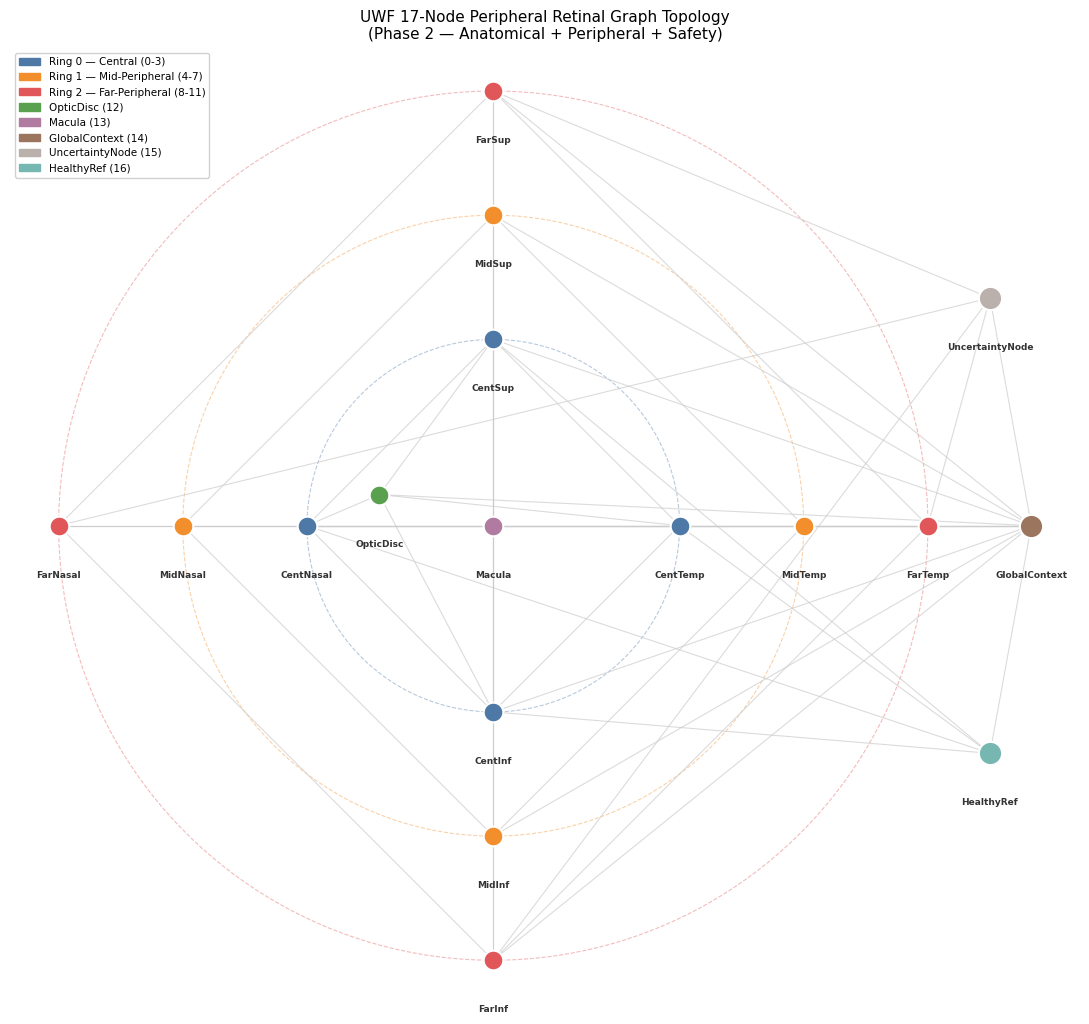


Visualising 17-node ROI layout on a sample UWF image...


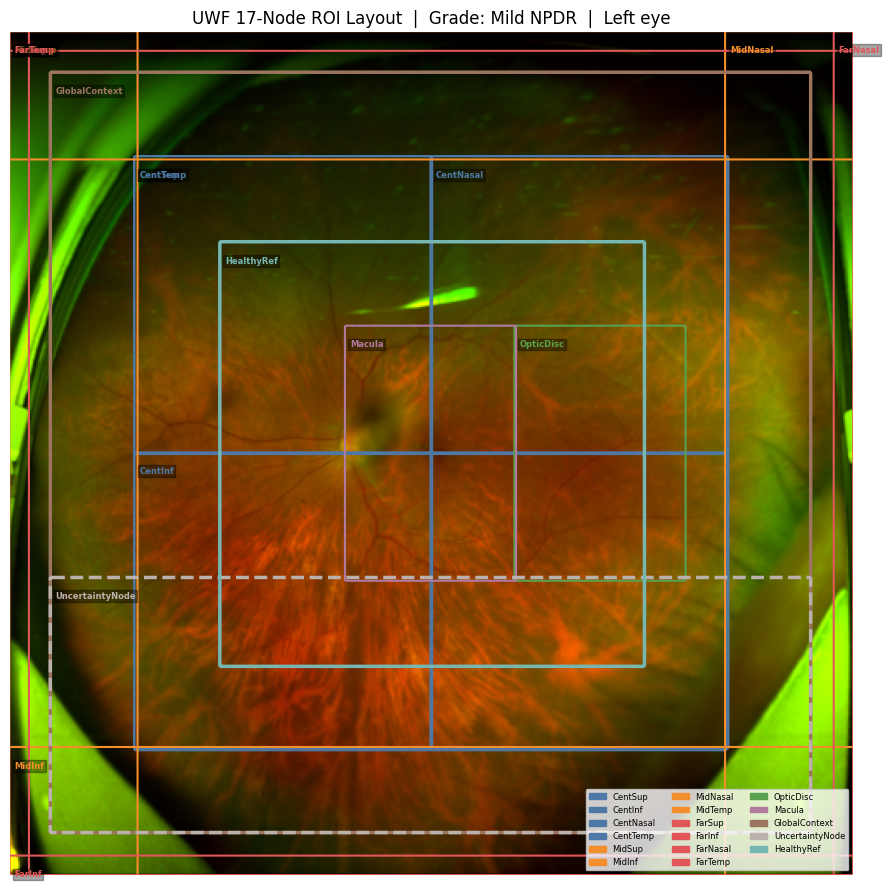


Debug forward pass...
── UWF Forward Pass Debug ─────────────────────────────
  Input images     : [2, 3, 512, 512]
  logits           : [2, 5]  NaN=False
  aux_logits       : [2, 5]  NaN=False
  ring2_conf       : [2, 4]  min=0.500  max=0.500
  ring0_attn   : [2, 4]  sum=1.000
  ring1_attn   : [2, 4]  sum=1.000
  ring2_attn   : [2, 4]  sum=1.000
  ring3_attn   : [2, 3]  sum=1.000
── Shapes OK ──────────────────────────────────────────

Training...
  Loss     : FocalLoss(γ=2.0)
  UWF aug  : enabled
  Aux wt   : 0.3
  Ep   1/50 | loss=0.7043 | val_acc=0.6680 | val_f1=0.6467 | 121s | session=0.58h
  Ep   2/50 | loss=0.4679 | val_acc=0.6629 | val_f1=0.6460 | 116s | session=0.61h
  Ep   3/50 | loss=0.4259 | val_acc=0.7059 | val_f1=0.6726 | 115s | session=0.64h
  Ep   4/50 | loss=0.3723 | val_acc=0.5605 | val_f1=0.5704 | 126s | session=0.67h
  Ep   5/50 | loss=0.3617 | val_acc=0.6424 | val_f1=0.6432 | 119s | session=0.71h
  Ep   6/50 | loss=0.3420 | val_acc=0.6742 | val_f1=0.6466 | 120s | 

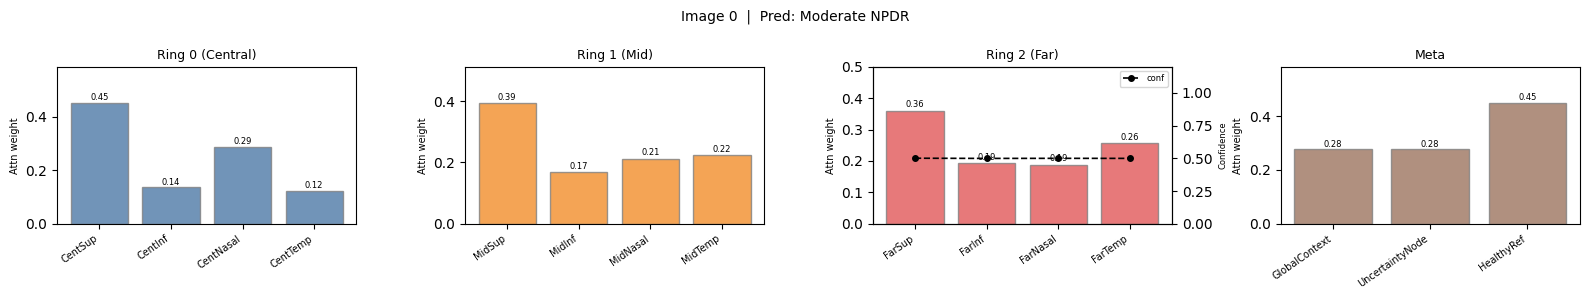

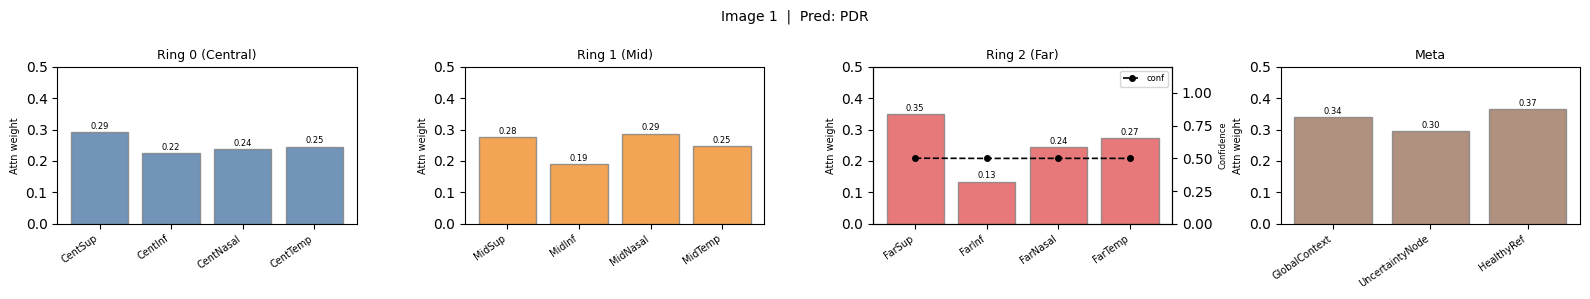

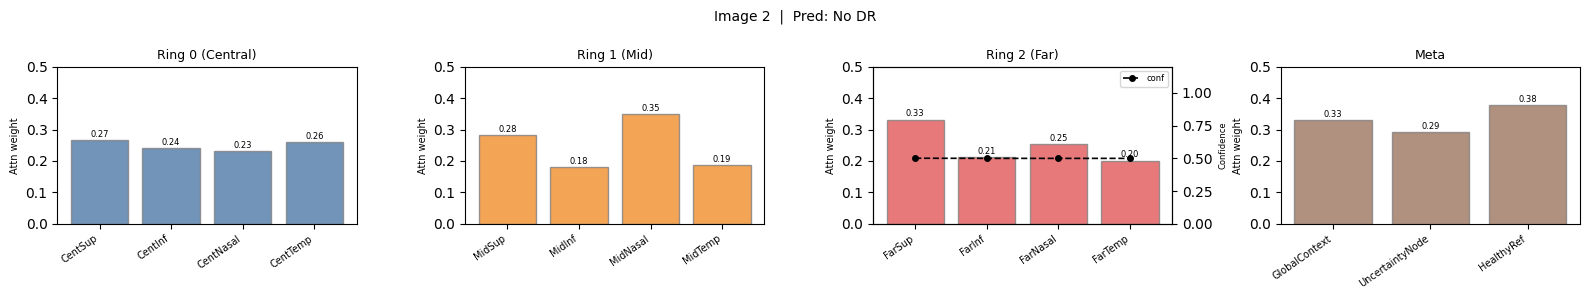

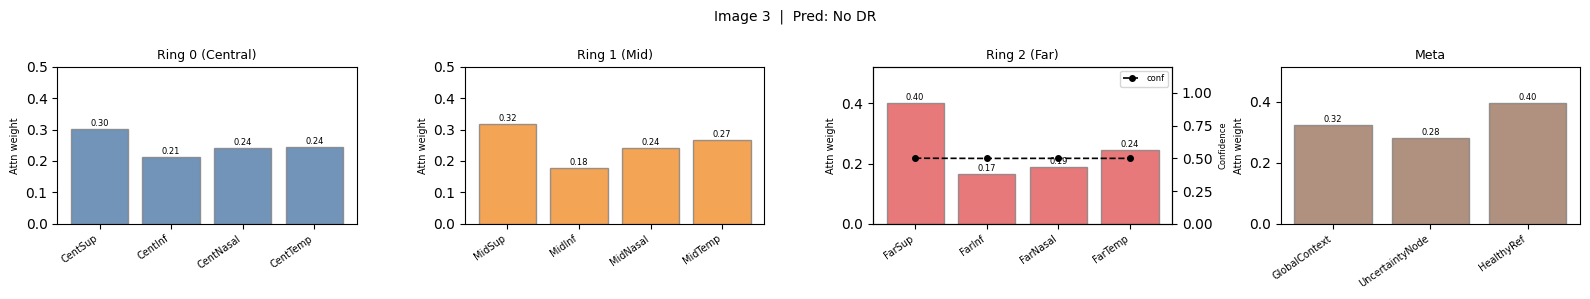


Visualising peripheral confidence...


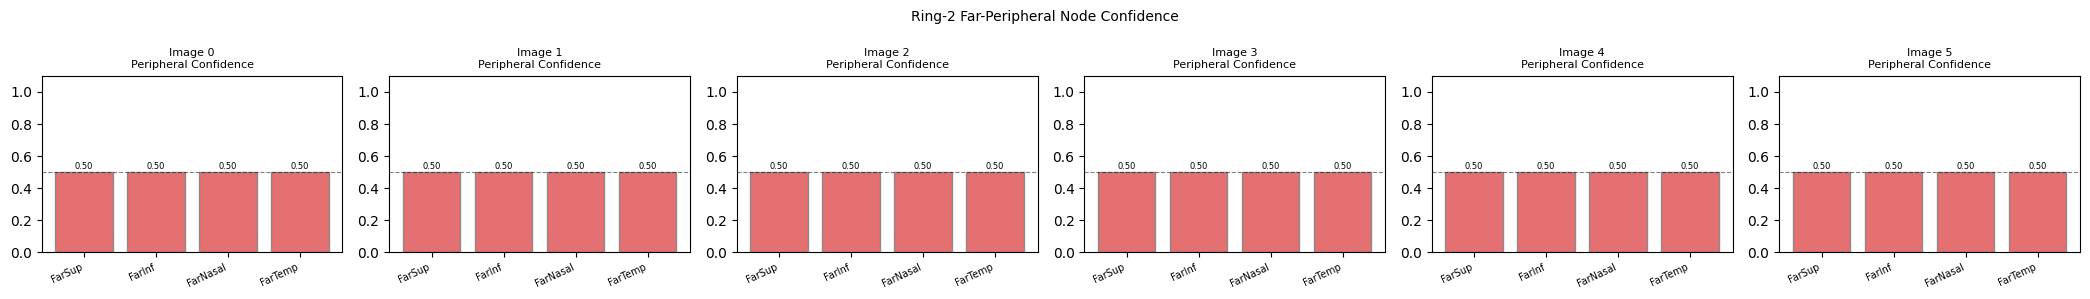


UWF GAT model freed from GPU.


In [18]:
# Task 2B — UWF DR Grading: Peripheral Anatomical GAT (Phase 2)

print('=' * 65)
print('TASK 2B: UWF DR Grading — Peripheral Anatomical GAT (Phase 2)')
print(f'Session: {hours_elapsed():.2f}h')
print('=' * 65)

# ── 0. Ensure parts contains Path objects ────────────────────────────────
parts = [Path(p) if isinstance(p, str) else p for p in parts]
assert all(p.exists() for p in parts), (
    'One or more zip parts missing. Re-run Cell 2.'
)
print(f'  Zip parts OK: {len(parts)} parts')

# ── 1. Extract UWF modality if not already done ───────────────────────────
if 'UWF_DIR' not in globals() or UWF_DIR is None or not Path(str(UWF_DIR)).exists():
    print('Extracting UWF modality...')
    UWF_DIR = extract_modality('MMRDR-UWF')
else:
    print('UWF already extracted — skipping.')
print(f'  UWF_DIR = {UWF_DIR}')

# ── 2. CSV splits ─────────────────────────────────────────────────────────
print('\nLoading CSV splits...')
uwf_train, uwf_val, uwf_test = load_csv_splits(UWF_DIR, 'UWF.csv')

# ── 3. DataLoaders ────────────────────────────────────────────────────────
print('Building UWF GAT DataLoaders...')
tr_uwf, vl_uwf, ts_uwf = make_loaders_gat(uwf_train, uwf_val, uwf_test, UWF_DIR)
print(f'  Train: {len(tr_uwf)} batches | Val: {len(vl_uwf)} | Test: {len(ts_uwf)}')

# ── 4. Class weights ──────────────────────────────────────────────────────
uwf_class_weights = compute_class_weights(uwf_train, n_classes=5, label_col='grade')
print('  Class weights (grade 0-4):',
      [f'{w:.3f}' for w in uwf_class_weights.cpu().tolist()])

# ── 5. Build model ────────────────────────────────────────────────────────
print('\nBuilding UWFRetinalGATClassifier...')
uwf_gat_model = build_uwf_gat_model(
    n_classes=5, proj_dim=256, n_heads=4,
    n_gat_layers=3, dropout=0.15, aux_weight=0.3,
)
print()
print_uwf_model_summary(uwf_gat_model)

# ── 6. Graph topology + ROI visualisation ────────────────────────────────
print('\nGraph topology:')
visualize_uwf_graph_topology()

print('\nVisualising 17-node ROI layout on a sample UWF image...')
_uwf_sample_ds = MMRDRGradingDatasetGAT(uwf_train.head(1), UWF_DIR, val_test_transform)
_uwf_sample_img, _uwf_sample_lr, _uwf_sample_lbl = _uwf_sample_ds[0]
visualize_uwf_roi_regions(
    _uwf_sample_img, lr=_uwf_sample_lr,
    title=(f'UWF 17-Node ROI Layout  |  Grade: {DR_GRADE_NAMES[_uwf_sample_lbl]}'
           f'  |  {"Right" if _uwf_sample_lr == 1 else "Left"} eye'),
)

# ── 7. Debug forward pass ─────────────────────────────────────────────────
print('\nDebug forward pass...')
debug_uwf_forward(uwf_gat_model, n_images=2)

# ── 8. Train ─────────────────────────────────────────────────────────────
if not session_ok(buffer_hrs=1.0):
    print('Session limit approaching — skipping UWF GAT training.')
else:
    print('\nTraining...')
    uwf_gat_ckpt = train_task_uwf(
        uwf_gat_model, tr_uwf, vl_uwf,
        task_name='uwf_grading_gat_phase2',
        class_weights=uwf_class_weights,
        aux_weight=0.3,
        use_focal=True,
        focal_gamma=2.0,
        use_uwf_aug=True,
    )

    # ── 9. Load best checkpoint ───────────────────────────────────────────
    print('\nLoading best checkpoint...')
    load_uwf_gat_checkpoint(uwf_gat_model, uwf_gat_ckpt)

    # ── 10. Evaluate on test set ──────────────────────────────────────────
    print('Evaluating on test set...')
    acc_uwf, f1_uwf, test_ring_attns, test_ring2_conf = evaluate_uwf(
        uwf_gat_model, ts_uwf
    )
    log_results('UWF_Grading_GAT_Phase2', acc_uwf, f1_uwf,
                paper_acc=0.798, paper_f1=0.671)

    # ── 11. Comparison table ──────────────────────────────────────────────
    print()
    print('  ─── Performance Comparison ──────────────────────────────────')
    for key in ['UWF_Grading', 'CFP_Grading', 'CFP_Grading_GAT',
                'UWF_Grading_GAT_Phase2']:
        r = RESULTS.get(key)
        if r:
            print(f'  {key:<30} acc={r["acc"]:.4f}  f1={r["f1"]:.4f}')

    # ── 12. Ring attention + peripheral confidence visualisation ──────────
    print('\nVisualising ring attention on test samples...')
    _vis_imgs, _vis_lr, _vis_lbl = next(iter(ts_uwf))
    _vis_imgs_d = _vis_imgs.to(DEVICE)
    _vis_lr_d   = _vis_lr.to(DEVICE)
    with torch.no_grad():
        _vis_logits, _, _vis_rattn, _vis_conf = uwf_gat_model(_vis_imgs_d, _vis_lr_d)
    _vis_preds = _vis_logits.argmax(dim=1).cpu().numpy()

    visualize_uwf_ring_attention(
        [ra.cpu() for ra in _vis_rattn],
        ring2_conf_batch=_vis_conf.cpu(),
        grade_preds=_vis_preds,
        grade_names=DR_GRADE_NAMES,
        max_show=4,
    )

    print('\nVisualising peripheral confidence...')
    visualize_uwf_peripheral_conf(_vis_conf.cpu(), max_show=6)

    # ── 13. Clean up ──────────────────────────────────────────────────────
    _cleanup_uwf(uwf_gat_model)
    print('\nUWF GAT model freed from GPU.')